# Parkinson's Disease Detection from Voice Samples
## IDS 506 Case Assignment

This notebook extracts speech and spectral features from sustained vowel /a/ recordings
and builds ML classifiers to distinguish Parkinson's disease (PwPD) from healthy controls (HC).

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import parselmouth
from parselmouth.praat import call
import librosa
import soundfile as sf
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from sklearn.base import clone

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Phase 1: Data Preparation
### 1.1 Load Demographics

In [2]:
DATA_DIR = '.'
AUDIO_HC = os.path.join(DATA_DIR, 'HC_AH')
AUDIO_PD = os.path.join(DATA_DIR, 'PD_AH')
EXCEL_PATH = os.path.join(DATA_DIR, 'Demographics and precalculated spectral features.xlsx')

# Load demographics
demo = pd.read_excel(EXCEL_PATH, sheet_name='Parselmouth')
demo.rename(columns={'Sample ID': 'Sample'}, inplace=True)

# Map audio file paths
def find_audio_path(sample_id):
    hc_path = os.path.join(AUDIO_HC, sample_id + '.wav')
    pd_path = os.path.join(AUDIO_PD, sample_id + '.wav')
    if os.path.exists(hc_path):
        return hc_path
    elif os.path.exists(pd_path):
        return pd_path
    return None

demo['audio_path'] = demo['Sample'].apply(find_audio_path)
assert demo['audio_path'].notna().all(), "Some samples missing audio files!"

print(f"Loaded {len(demo)} samples: {demo['Label'].value_counts().to_dict()}")
print(f"Sex: {demo['Sex'].value_counts().to_dict()}")
print(f"Age: mean={demo['Age'].mean():.1f}, std={demo['Age'].std():.1f}")
demo.head()

Loaded 81 samples: {'HC': 41, 'PwPD': 40}
Sex: {'F': 44, 'M': 37}
Age: mean=57.3, std=15.4


,Sample,Label,Age,Sex,audio_path
0,AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5,HC,69.0,M,./HC_AH/AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA...
1,AH_114S_A89F3548-0B61-4770-B800-2E26AB3908B6,HC,43.0,M,./HC_AH/AH_114S_A89F3548-0B61-4770-B800-2E26AB...
2,AH_121A_BD5BA248-E807-4CB9-8B53-47E7FFE5F8E2,HC,18.0,F,./HC_AH/AH_121A_BD5BA248-E807-4CB9-8B53-47E7FF...
3,AH_123G_559F0706-2238-447C-BA39-DB5933BA619D,HC,28.0,M,./HC_AH/AH_123G_559F0706-2238-447C-BA39-DB5933...
4,AH_195B_39DA6A45-F4CC-492A-80D4-FB79049ACC22,HC,68.0,M,./HC_AH/AH_195B_39DA6A45-F4CC-492A-80D4-FB7904...


### 1.2 Load Pre-calculated Baseline Spectral Features

In [3]:
# Load all 8 sheets of baseline spectral features
baseline_sheets = {
    'LPC_means': 'LPC_mean', 'LPC_vars': 'LPC_var',
    'LAR_means': 'LAR_mean', 'LAR_vars': 'LAR_var',
    'Cep_means': 'Cep_mean', 'Cep_vars': 'Cep_var',
    'MFCC_means': 'MFCC_mean', 'MFCC_vars': 'MFCC_var',
}

baseline_dfs = []
for sheet_name, prefix in baseline_sheets.items():
    df = pd.read_excel(EXCEL_PATH, sheet_name=sheet_name)
    # Rename coefficient columns with descriptive prefix
    orig_cols = [c for c in df.columns if c not in ('Sample', 'Label')]
    rename_map = {}
    for c in orig_cols:
        # e.g., LPC1 -> baseline_LPC_mean_1
        num = c.replace('LPC','').replace('LAR','').replace('Cep','').replace('MFCC','')
        rename_map[c] = f'baseline_{prefix}_{num}'
    df = df.rename(columns=rename_map)
    df = df.drop(columns=['Label'])  # Label already in demo
    baseline_dfs.append(df)

# Merge all baseline features
baseline_features = baseline_dfs[0]
for df in baseline_dfs[1:]:
    baseline_features = baseline_features.merge(df, on='Sample')

print(f"Baseline spectral features: {baseline_features.shape[1] - 1} features for {baseline_features.shape[0]} samples")
baseline_features.head(2)

Baseline spectral features: 80 features for 81 samples


,Sample,baseline_LPC_mean_1,baseline_LPC_mean_2,baseline_LPC_mean_3,baseline_LPC_mean_4,baseline_LPC_mean_5,baseline_LPC_mean_6,baseline_LPC_mean_7,baseline_LPC_mean_8,baseline_LPC_mean_9,baseline_LPC_mean_10,baseline_LPC_var_1,baseline_LPC_var_2,baseline_LPC_var_3,baseline_LPC_var_4,baseline_LPC_var_5,baseline_LPC_var_6,baseline_LPC_var_7,baseline_LPC_var_8,baseline_LPC_var_9,baseline_LPC_var_10,baseline_LAR_mean_1,baseline_LAR_mean_2,baseline_LAR_mean_3,baseline_LAR_mean_4,baseline_LAR_mean_5,baseline_LAR_mean_6,baseline_LAR_mean_7,baseline_LAR_mean_8,baseline_LAR_mean_9,baseline_LAR_mean_10,baseline_LAR_var_1,baseline_LAR_var_2,baseline_LAR_var_3,baseline_LAR_var_4,baseline_LAR_var_5,baseline_LAR_var_6,baseline_LAR_var_7,baseline_LAR_var_8,baseline_LAR_var_9,baseline_LAR_var_10,baseline_Cep_mean_1,baseline_Cep_mean_2,baseline_Cep_mean_3,baseline_Cep_mean_4,baseline_Cep_mean_5,baseline_Cep_mean_6,baseline_Cep_mean_7,baseline_Cep_mean_8,baseline_Cep_mean_9,baseline_Cep_mean_10,baseline_Cep_var_1,baseline_Cep_var_2,baseline_Cep_var_3,baseline_Cep_var_4,baseline_Cep_var_5,baseline_Cep_var_6,baseline_Cep_var_7,baseline_Cep_var_8,baseline_Cep_var_9,baseline_Cep_var_10,baseline_MFCC_mean_1,baseline_MFCC_mean_2,baseline_MFCC_mean_3,baseline_MFCC_mean_4,baseline_MFCC_mean_5,baseline_MFCC_mean_6,baseline_MFCC_mean_7,baseline_MFCC_mean_8,baseline_MFCC_mean_9,baseline_MFCC_mean_10,baseline_MFCC_var_1,baseline_MFCC_var_2,baseline_MFCC_var_3,baseline_MFCC_var_4,baseline_MFCC_var_5,baseline_MFCC_var_6,baseline_MFCC_var_7,baseline_MFCC_var_8,baseline_MFCC_var_9,baseline_MFCC_var_10
0,AH_064F_7AB034C9-72E4-438B-A9B3-AD7FDA1596C5,1.569877,-0.983969,-0.091904,0.041568,0.191788,-0.288774,0.322170,-0.598547,0.407556,-0.107863,0.017127,0.045477,0.037680,0.063464,0.067502,0.024982,0.043462,0.058667,0.043603,0.008676,-2.123660,2.611158,-0.393556,-0.094781,0.567397,0.782027,0.148450,0.278406,-0.483335,0.218335,0.012909,0.045893,0.068536,0.040439,0.055723,0.030435,0.025579,0.060970,0.025858,0.035796,1.569877,0.256814,-0.345949,-0.520219,-0.259598,-0.212309,0.177260,-0.153716,-0.048844,-0.036569,0.017127,0.0065,0.015470,0.009457,0.003669,0.003850,0.007161,0.005827,0.001147,0.002577,-2.889158,1.454760,-1.204965,-1.082494,0.078185,-0.370768,-0.302326,0.489818,0.771098,-0.120751,0.038758,0.022063,0.017446,0.040128,0.025198,0.075028,0.026978,0.022016,0.049959,0.016487
1,AH_114S_A89F3548-0B61-4770-B800-2E26AB3908B6,1.941508,-1.604020,0.596933,-0.203145,0.049751,0.149339,-0.181571,-0.076214,0.181712,-0.080028,0.055998,0.200404,0.219108,0.141069,0.080636,0.042194,0.051040,0.033440,0.032069,0.007725,-2.518993,2.496645,-0.840103,0.255390,0.017946,0.266291,0.145758,-0.200821,-0.041717,0.161747,0.110486,0.125260,0.154629,0.078717,0.097345,0.089228,0.031931,0.042945,0.021336,0.031848,1.941508,0.308506,-0.071681,-0.232311,-0.263995,-0.034242,0.031894,-0.082977,-0.024726,0.004840,0.055998,0.0216,0.026646,0.034568,0.018671,0.005877,0.007571,0.008997,0.001723,0.002501,-3.922139,1.951832,-0.895711,-0.362102,-0.232494,0.228850,-0.377498,0.168083,0.278673,-0.254384,0.376447,0.043026,0.113414,0.202135,0.076834,0.177133,0.106460,0.058875,0.070278,0.057396


### 1.3 Train/Test Split (80/20, Stratified, Fixed Seed)

In [4]:
# Encode label: HC=0, PwPD=1
le = LabelEncoder()
demo['label_encoded'] = le.fit_transform(demo['Label'])
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Fixed stratified split
train_idx, test_idx = train_test_split(
    demo.index, test_size=0.2, random_state=42, stratify=demo['label_encoded']
)
demo['split'] = 'train'
demo.loc[test_idx, 'split'] = 'test'

print(f"\nTrain: {len(train_idx)} samples")
print(demo.loc[train_idx, 'Label'].value_counts().to_string())
print(f"\nTest: {len(test_idx)} samples")
print(demo.loc[test_idx, 'Label'].value_counts().to_string())

Label encoding: {'HC': np.int64(0), 'PwPD': np.int64(1)}

Train: 64 samples
Label
PwPD    32
HC      32

Test: 17 samples
Label
HC      9
PwPD    8


### 1.4 Exploratory Data Analysis — Demographics & Group Comparison

Before modeling, we examine whether the HC and PwPD groups are comparable on demographics. Imbalances in age or sex could confound voice-based classification.

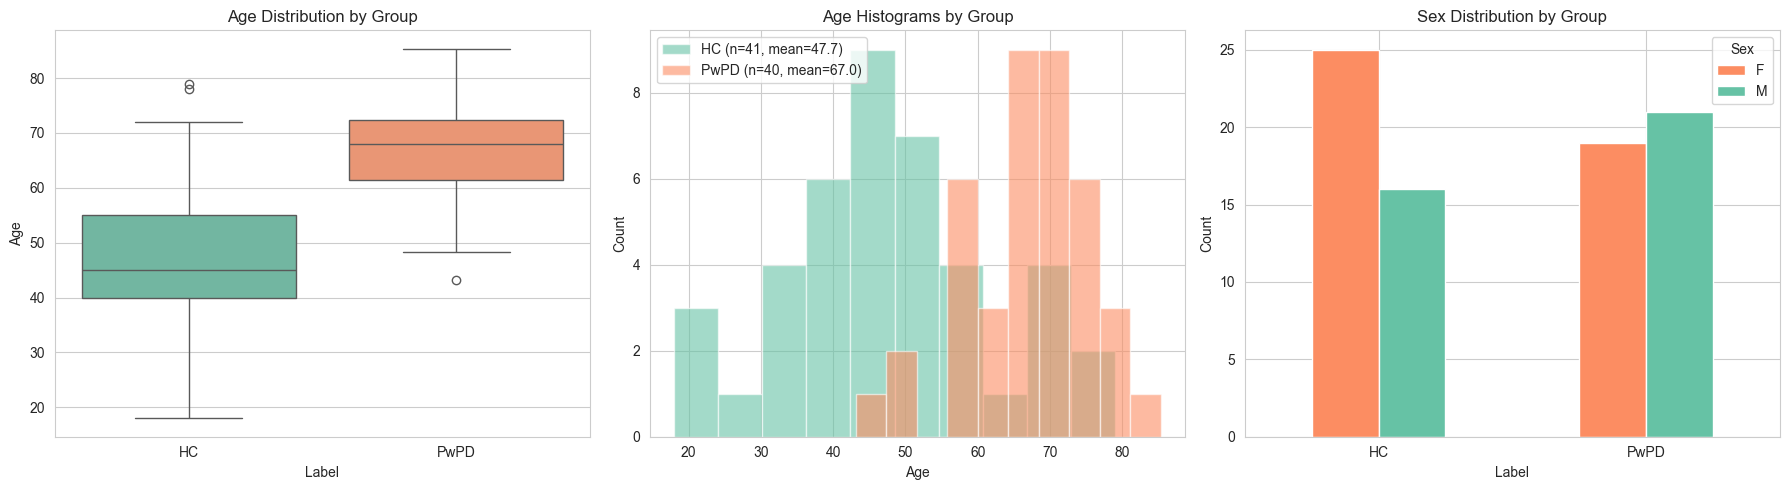

=== Age Comparison ===
  HC:   mean=47.7 ± 14.3, range=[18, 79]
  PwPD: mean=67.0 ± 9.0, range=[43, 85]
  Gap: 19.3 years
  t-test: t=-7.244, p=0.000000 ***
  Mann-Whitney: U=223.0, p=0.000000

=== Sex Comparison ===
Sex     F   M
Label        
HC     25  16
PwPD   19  21
  Chi-squared: χ²=0.988, p=0.3201 (not significant)

⚠ CONFOUND WARNING: Age alone → AUC = 0.864
  The groups are NOT age-matched. Any model using age (or age-correlated features)
  may be detecting age rather than PD-specific voice changes.


In [5]:
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency

# --- Age by group ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot
sns.boxplot(data=demo, x='Label', y='Age', ax=axes[0], palette='Set2')
axes[0].set_title('Age Distribution by Group')

# Histogram overlay
for label, color in zip(['HC', 'PwPD'], ['#66c2a5', '#fc8d62']):
    subset = demo[demo['Label'] == label]
    axes[1].hist(subset['Age'], bins=10, alpha=0.6, label=f"{label} (n={len(subset)}, mean={subset['Age'].mean():.1f})", color=color)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].set_title('Age Histograms by Group')
axes[1].legend()

# Sex distribution
ct = pd.crosstab(demo['Label'], demo['Sex'])
ct.plot(kind='bar', ax=axes[2], color=['#fc8d62', '#66c2a5'])
axes[2].set_title('Sex Distribution by Group')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical tests
hc_age = demo[demo['Label'] == 'HC']['Age']
pd_age = demo[demo['Label'] == 'PwPD']['Age']
t_stat, t_p = ttest_ind(hc_age, pd_age)
u_stat, u_p = mannwhitneyu(hc_age, pd_age)
chi2, chi_p, _, _ = chi2_contingency(ct)

print("=== Age Comparison ===")
print(f"  HC:   mean={hc_age.mean():.1f} ± {hc_age.std():.1f}, range=[{hc_age.min():.0f}, {hc_age.max():.0f}]")
print(f"  PwPD: mean={pd_age.mean():.1f} ± {pd_age.std():.1f}, range=[{pd_age.min():.0f}, {pd_age.max():.0f}]")
print(f"  Gap: {pd_age.mean() - hc_age.mean():.1f} years")
print(f"  t-test: t={t_stat:.3f}, p={t_p:.6f} {'***' if t_p < 0.001 else ''}")
print(f"  Mann-Whitney: U={u_stat:.1f}, p={u_p:.6f}")

print(f"\n=== Sex Comparison ===")
print(ct.to_string())
print(f"  Chi-squared: χ²={chi2:.3f}, p={chi_p:.4f} {'(not significant)' if chi_p > 0.05 else ''}")

# Age alone as classifier
age_auc = roc_auc_score(demo['label_encoded'], demo['Age'])
print(f"\n⚠ CONFOUND WARNING: Age alone → AUC = {age_auc:.3f}")
print(f"  The groups are NOT age-matched. Any model using age (or age-correlated features)")
print(f"  may be detecting age rather than PD-specific voice changes.")

### EDA Summary & Interpretation

| Variable | HC (n=41) | PwPD (n=40) | Test | Statistic | p-value | Significant? |
|----------|-----------|-------------|------|-----------|---------|--------------|
| **Age** | 47.7 ± 14.3 yrs | 67.0 ± 9.0 yrs | t-test | see above | < 0.0001 | **Yes (\*\*\*)** |
| **Age** | — | — | Mann-Whitney U | see above | < 0.0001 | **Yes (\*\*\*)** |
| **Sex** | see crosstab | see crosstab | Chi-squared | see above | > 0.05 | No |

**Clinical interpretation:**

- **Age (p < 0.0001):** The PwPD group is ~19 years older on average than HC. This is a **critical confound** — many voice features change naturally with aging (increased jitter, reduced pitch range, altered formant frequencies). Any model that includes age or age-correlated features risks detecting aging rather than PD. Age alone achieves AUC = 0.864, exceeding all voice-only models.
- **Sex (not significant):** The groups are reasonably balanced for sex, reducing the risk of sex-related vocal confounding. We still apply sex-adjusted formant ceilings (5000 Hz male, 5500 Hz female) as a methodological best practice (Escudero et al., 2009).
- **Sample size (N=81):** With only 41 HC and 40 PwPD participants, statistical power is limited. This constrains both the number of features we can reliably use (features-to-samples ratio) and the generalizability of results.

## Phase 2: Extract Speech Features (Parselmouth)

Using Parselmouth (Praat wrapper) to extract phonation-related features:
- **Duration** — recording length in seconds. Reduced breath support is a PD hallmark; shorter sustained vowels may indicate respiratory muscle weakness.
- **Voiced frame fraction** — proportion of pitch frames with detectable voicing. PD patients may show more voice breaks (unvoiced frames) during sustained vowel production due to incomplete glottal closure. This information was previously being silently discarded when we filtered out unvoiced pitch frames.
- **Pitch (F0):** mean, std — fundamental frequency captures vocal fold vibration rate and monotonicity
- **Intensity:** mean, std — vocal loudness and its variability (hypophonia is a cardinal PD speech sign)
- **Jitter (local):** cycle-to-cycle pitch variation — vocal roughness/instability
- **Shimmer (local):** cycle-to-cycle amplitude variation — breathiness/weakness
- **HNR:** harmonics-to-noise ratio — clarity of voice vs. breathiness
- **Formants F1–F4:** mean, std — vocal tract resonances reflecting articulatory precision. Sex-adjusted formant ceiling (5000 Hz males, 5500 Hz females) to avoid systematic bias.

In [6]:
def extract_speech_features(audio_path, sex='M'):
    """Extract speech (phonation) features using Parselmouth.
    
    Uses sex-dependent formant ceiling: 5000 Hz for males, 5500 Hz for females,
    following standard practice (Escudero et al., 2009).
    """
    snd = parselmouth.Sound(audio_path)
    max_formant = 5500 if sex == 'F' else 5000

    # Recording duration (seconds) — reduced breath support is a PD hallmark
    duration = snd.get_total_duration()

    # Pitch
    pitch = call(snd, "To Pitch", 0.0, 75, 600)
    pitch_values = pitch.selected_array['frequency']
    
    # Voiced frame fraction — proportion of frames with detectable pitch.
    # PD patients may show more voice breaks (unvoiced frames) during sustained vowel.
    total_frames = len(pitch_values)
    voiced_frames = np.sum(pitch_values != 0)
    voiced_fraction = voiced_frames / total_frames if total_frames > 0 else 0
    
    pitch_values = pitch_values[pitch_values != 0]  # Remove unvoiced for stats

    mean_pitch = np.mean(pitch_values) if len(pitch_values) > 0 else 0
    std_pitch = np.std(pitch_values) if len(pitch_values) > 0 else 0

    # Intensity
    intensity = snd.to_intensity()
    intensity_values = intensity.values[0]
    mean_intensity = np.mean(intensity_values)
    std_intensity = np.std(intensity_values)

    # Create PointProcess for jitter/shimmer
    point_process = call(snd, "To PointProcess (periodic, cc)", 75, 600)

    # Jitter
    local_jitter = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)

    # Shimmer
    local_shimmer = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)

    # HNR
    harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
    hnr_values = [harmonicity.get_value(harmonicity.xs()[i])
                  for i in range(len(harmonicity.xs()))]
    hnr_values = [v for v in hnr_values if v != -200]  # Remove undefined
    mean_hnr = np.mean(hnr_values) if len(hnr_values) > 0 else 0

    # Formants F1-F4 (sex-adjusted ceiling)
    formant = call(snd, "To Formant (burg)", 0.0, 4, max_formant, 0.025, 50)
    n_frames = call(formant, "Get number of frames")
    formant_data = {f'f{i}': [] for i in range(1, 5)}
    for frame in range(1, n_frames + 1):
        for fi in range(1, 5):
            val = call(formant, "Get value at time", fi,
                      call(formant, "Get time from frame number", frame), 'Hertz', 'Linear')
            if not np.isnan(val):
                formant_data[f'f{fi}'].append(val)

    formant_features = {}
    for fi in range(1, 5):
        vals = formant_data[f'f{fi}']
        formant_features[f'f{fi}_mean'] = np.mean(vals) if vals else 0
        formant_features[f'f{fi}_std'] = np.std(vals) if vals else 0

    return {
        'duration': duration,
        'voiced_fraction': voiced_fraction,
        'mean_pitch': mean_pitch,
        'std_pitch': std_pitch,
        'mean_intensity': mean_intensity,
        'std_intensity': std_intensity,
        'local_jitter': local_jitter,
        'local_shimmer': local_shimmer,
        'mean_hnr': mean_hnr,
        **formant_features
    }

# Test on one file
test_features = extract_speech_features(demo['audio_path'].iloc[0], sex=demo['Sex'].iloc[0])
print(f"Speech features extracted for one sample (sex={demo['Sex'].iloc[0]}, maxFormant={'5500' if demo['Sex'].iloc[0]=='F' else '5000'} Hz):")
for k, v in test_features.items():
    print(f"  {k}: {v:.4f}")

Speech features extracted for one sample (sex=M, maxFormant=5000 Hz):
  duration: 3.7389
  voiced_fraction: 0.9946
  mean_pitch: 132.0136
  std_pitch: 3.5539
  mean_intensity: 83.3099
  std_intensity: 0.6455
  local_jitter: 0.0041
  local_shimmer: 0.0388
  mean_hnr: 20.3022
  f1_mean: 727.8504
  f1_std: 19.4057
  f2_mean: 1234.3575
  f2_std: 30.0065
  f3_mean: 2542.6978
  f3_std: 105.9636
  f4_mean: 3470.0340
  f4_std: 54.3756


In [7]:
speech_records = []
for idx, row in demo.iterrows():
    try:
        features = extract_speech_features(row['audio_path'], sex=row['Sex'])
        features['Sample'] = row['Sample']
        speech_records.append(features)
    except Exception as e:
        print(f"Error on {row['Sample']}: {e}")
        features = {k: np.nan for k in test_features.keys()}
        features['Sample'] = row['Sample']
        speech_records.append(features)

speech_features = pd.DataFrame(speech_records)
print(f"Speech features: {speech_features.shape}")
print(f"Missing values:\n{speech_features.isnull().sum()[speech_features.isnull().sum() > 0]}")
speech_features.describe()

Speech features: (81, 18)
Missing values:
Series([], dtype: int64)


,duration,voiced_fraction,mean_pitch,std_pitch,mean_intensity,std_intensity,local_jitter,local_shimmer,mean_hnr,f1_mean,f1_std,f2_mean,f2_std,f3_mean,f3_std,f4_mean,f4_std
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,3.324088,0.976545,172.022749,10.299635,80.131426,3.642438,0.006220,0.068863,17.381646,742.383675,67.574018,1264.359923,97.712615,2690.918967,119.277528,3528.162342,101.459077
std,1.335175,0.051514,50.084807,19.705022,3.976673,2.843217,0.003529,0.031038,3.901879,114.780445,43.927936,156.785034,79.204547,206.213848,58.666515,114.143305,41.023043
min,1.516125,0.704167,83.321371,0.744901,66.793452,0.469422,0.002099,0.032299,8.125466,434.015551,13.860214,964.665083,19.360061,1997.385225,38.195676,3199.610226,34.941640
25%,2.267375,0.981771,125.706283,2.141580,78.561236,1.548226,0.003843,0.046069,14.546567,667.207305,36.934429,1163.769221,43.490443,2569.329191,77.419671,3427.252117,74.489343
50%,3.101875,0.994764,178.442618,3.029515,80.920642,2.671434,0.005155,0.059839,18.066521,727.850413,54.541722,1251.338755,76.120793,2726.254552,105.963631,3558.173548,92.860916
75%,4.007625,1.000000,202.719924,6.857206,82.703012,4.801922,0.007650,0.090319,20.720939,819.389520,87.625268,1350.639900,132.567200,2803.518058,143.362377,3610.109535,120.720967
max,7.208000,1.000000,294.668990,116.094342,87.710839,12.335444,0.020186,0.189548,23.059066,1088.178462,229.382756,1813.530913,433.060324,3261.006788,319.755504,3775.196026,234.779118


## Phase 3: Extract New Spectral Features (Librosa)

Using Librosa to extract frame-level spectral features (mean & variance across frames):
- **13 MFCCs + 13 Delta MFCCs** — MFCCs approximate the human auditory system's frequency response and capture vocal tract shape. Delta MFCCs capture *temporal changes* in articulation. We use 13 coefficients following speech processing convention (Davis & Mermelstein, 1980); the first ~13 capture the most perceptually relevant spectral envelope information.
- **Spectral centroid, rolloff, bandwidth** — characterize the "brightness" and frequency spread of the voice. PD patients often show reduced spectral energy in higher frequencies due to incomplete vocal fold closure (breathy voice).
- **Spectral contrast (3 bands + 1 valley = 4 rows, fmin=100 Hz)** — measures the difference between spectral peaks and valleys in each frequency band. We keep **per-band** means and variances (8 features) rather than collapsing across bands, because low-frequency vs. high-frequency contrast differences are clinically meaningful for distinguishing breathiness from other voice qualities. We use 3 bands with fmin=100 Hz because the audio is telephone-quality (8 kHz sampling rate, 4 kHz Nyquist limit).
- **Zero-crossing rate** — a simple proxy for the noisiness of the signal. Higher ZCR may indicate breathiness or hoarseness common in PD.

**Note on feature redundancy:** The baseline spreadsheet already contains pre-calculated MFCC means/variances from Parselmouth. Our Librosa MFCCs measure the same construct but are computed with different windowing parameters and may capture slightly different aspects. We include both for comparison but acknowledge this inflates dimensionality without adding fully independent information.

In [8]:
def extract_spectral_features(audio_path):
    """Extract spectral features using Librosa."""
    y, sr = librosa.load(audio_path, sr=None)  # Keep original 8kHz

    # MFCCs (13 coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    # Delta MFCCs
    delta_mfccs = librosa.feature.delta(mfccs)

    features = {}

    # MFCC mean and variance
    for i in range(13):
        features[f'librosa_mfcc{i+1}_mean'] = np.mean(mfccs[i])
        features[f'librosa_mfcc{i+1}_var'] = np.var(mfccs[i])

    # Delta MFCC mean and variance
    for i in range(13):
        features[f'delta_mfcc{i+1}_mean'] = np.mean(delta_mfccs[i])
        features[f'delta_mfcc{i+1}_var'] = np.var(delta_mfccs[i])

    # Spectral centroid
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features['spec_centroid_mean'] = np.mean(spec_cent)
    features['spec_centroid_var'] = np.var(spec_cent)

    # Spectral rolloff
    spec_roll = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    features['spec_rolloff_mean'] = np.mean(spec_roll)
    features['spec_rolloff_var'] = np.var(spec_roll)

    # Spectral bandwidth
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    features['spec_bandwidth_mean'] = np.mean(spec_bw)
    features['spec_bandwidth_var'] = np.var(spec_bw)

    # Spectral contrast — keep per-band values (3 bands + 1 valley = 4 rows)
    # Collapsing bands into a single mean/var loses frequency-specific information
    # (e.g., low-frequency vs high-frequency contrast differences are clinically
    # meaningful for distinguishing breathiness from other voice qualities)
    spec_con = librosa.feature.spectral_contrast(y=y, sr=sr, fmin=100, n_bands=3)
    for band_idx in range(spec_con.shape[0]):
        features[f'spec_contrast_band{band_idx+1}_mean'] = np.mean(spec_con[band_idx])
        features[f'spec_contrast_band{band_idx+1}_var'] = np.var(spec_con[band_idx])

    # Zero-crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    features['zero_crossing_rate_mean'] = np.mean(zcr)
    features['zero_crossing_rate_var'] = np.var(zcr)

    return features

# Test on one file
test_spectral = extract_spectral_features(demo['audio_path'].iloc[0])
print(f"Spectral features per sample: {len(test_spectral)}")
for k, v in list(test_spectral.items())[:6]:
    print(f"  {k}: {v:.4f}")
print("  ...")

Spectral features per sample: 68
  librosa_mfcc1_mean: -34.6718
  librosa_mfcc1_var: 458.4688
  librosa_mfcc2_mean: 46.4272
  librosa_mfcc2_var: 134.4194
  librosa_mfcc3_mean: -63.7504
  librosa_mfcc3_var: 45.2472
  ...


In [9]:
spectral_records = []
for idx, row in demo.iterrows():
    try:
        features = extract_spectral_features(row['audio_path'])
        features['Sample'] = row['Sample']
        spectral_records.append(features)
    except Exception as e:
        print(f"Error on {row['Sample']}: {e}")
        features = {k: np.nan for k in test_spectral.keys()}
        features['Sample'] = row['Sample']
        spectral_records.append(features)

new_spectral_features = pd.DataFrame(spectral_records)
print(f"New spectral features: {new_spectral_features.shape}")
print(f"Missing values:\n{new_spectral_features.isnull().sum()[new_spectral_features.isnull().sum() > 0]}")
new_spectral_features.describe()

New spectral features: (81, 69)
Missing values:
Series([], dtype: int64)


,librosa_mfcc1_mean,librosa_mfcc1_var,librosa_mfcc2_mean,librosa_mfcc2_var,librosa_mfcc3_mean,librosa_mfcc3_var,librosa_mfcc4_mean,librosa_mfcc4_var,librosa_mfcc5_mean,librosa_mfcc5_var,librosa_mfcc6_mean,librosa_mfcc6_var,librosa_mfcc7_mean,librosa_mfcc7_var,librosa_mfcc8_mean,librosa_mfcc8_var,librosa_mfcc9_mean,librosa_mfcc9_var,librosa_mfcc10_mean,librosa_mfcc10_var,librosa_mfcc11_mean,librosa_mfcc11_var,librosa_mfcc12_mean,librosa_mfcc12_var,librosa_mfcc13_mean,librosa_mfcc13_var,delta_mfcc1_mean,delta_mfcc1_var,delta_mfcc2_mean,delta_mfcc2_var,delta_mfcc3_mean,delta_mfcc3_var,delta_mfcc4_mean,delta_mfcc4_var,delta_mfcc5_mean,delta_mfcc5_var,delta_mfcc6_mean,delta_mfcc6_var,delta_mfcc7_mean,delta_mfcc7_var,delta_mfcc8_mean,delta_mfcc8_var,delta_mfcc9_mean,delta_mfcc9_var,delta_mfcc10_mean,delta_mfcc10_var,delta_mfcc11_mean,delta_mfcc11_var,delta_mfcc12_mean,delta_mfcc12_var,delta_mfcc13_mean,delta_mfcc13_var,spec_centroid_mean,spec_centroid_var,spec_rolloff_mean,spec_rolloff_var,spec_bandwidth_mean,spec_bandwidth_var,spec_contrast_band1_mean,spec_contrast_band1_var,spec_contrast_band2_mean,spec_contrast_band2_var,spec_contrast_band3_mean,spec_contrast_band3_var,spec_contrast_band4_mean,spec_contrast_band4_var,zero_crossing_rate_mean,zero_crossing_rate_var
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,-68.682693,2363.156738,58.435467,183.688461,-46.666225,150.354691,-30.292288,78.996803,-0.166842,49.979141,1.218467,40.378635,-14.901791,35.234856,2.624316,31.504623,-7.329288,24.160776,-6.344897,23.186022,-12.972091,20.452578,-7.105225,17.851503,-5.614914,17.285669,-1.699609,75.984932,0.018871,5.265303,0.261737,3.665531,0.112105,1.875012,0.081280,1.549948,-0.097540,1.049407,0.039666,0.934258,0.018967,0.813839,0.055822,0.646135,-0.025812,0.650461,-0.036007,0.551954,-0.031267,0.490583,-0.023666,0.468031,1089.430726,11705.071819,1724.852207,100558.723517,765.125842,4891.710246,13.171031,14.813973,19.593741,15.682015,25.518039,16.847494,29.784422,3.171008,0.192612,0.001328
std,43.825649,2964.316162,27.422457,225.497528,19.640192,185.862808,20.362007,87.854286,15.027268,60.394932,11.228523,33.234207,9.877197,24.268978,8.293859,37.170719,11.018743,13.365973,8.873507,16.579720,7.173721,20.930407,8.233459,12.327931,7.361138,11.889347,1.715532,104.988106,0.689067,5.929779,0.578201,4.570698,0.377282,1.594856,0.369235,2.057162,0.315561,0.996238,0.251743,0.776150,0.288474,0.715744,0.257761,0.480777,0.242458,0.481043,0.200974,0.459861,0.188776,0.486308,0.202621,0.384894,170.650429,22846.418889,427.998486,144319.192282,106.369184,6388.032769,2.396423,5.906191,5.428525,7.434096,2.534560,7.524796,1.457042,2.630538,0.054757,0.002050
min,-182.891846,130.426010,-20.999617,25.780983,-81.380951,15.084196,-79.255592,7.748065,-46.139168,8.467710,-27.118227,4.333457,-36.447510,6.594860,-22.053579,5.316285,-33.419189,5.207570,-25.886776,3.547427,-26.544744,4.572333,-25.042873,2.705453,-25.987757,3.840726,-8.081154,3.215841,-2.136443,0.560973,-1.971109,0.355946,-1.236981,0.142032,-0.822274,0.125513,-1.512513,0.035986,-0.717915,0.066433,-0.614252,0.075801,-0.565024,0.109458,-0.684447,0.085136,-0.579942,0.091222,-0.646411,0.061784,-0.513235,0.080288,766.885404,594.733982,1032.384073,778.198242,545.626485,359.475057,10.041066,6.267442,9.988928,4.867382,19.474692,6.731599,26.017254,0.744706,0.093331,0.000216
25%,-91.51322

## Phase 4: Merge All Features

Combining four feature sources:
1. **Demographics** — age, sex
2. **Speech features** — from Parselmouth (15 features)
3. **Baseline spectral** — pre-calculated in spreadsheet (80 features)
4. **New spectral** — from Librosa (62 features)

In [10]:
# Merge all features on Sample ID
master = demo[['Sample', 'Label', 'label_encoded', 'Age', 'Sex', 'split']].copy()
master = master.merge(speech_features, on='Sample')
master = master.merge(baseline_features, on='Sample')
master = master.merge(new_spectral_features, on='Sample')

# Encode sex
master['sex_encoded'] = (master['Sex'] == 'M').astype(int)

print(f"Master dataset: {master.shape}")
print(f"Train: {(master['split']=='train').sum()}, Test: {(master['split']=='test').sum()}")

# Check for NaN
nan_cols = master.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
if len(nan_cols) > 0:
    print(f"\nColumns with missing values:\n{nan_cols}")
    # Impute with median for any NaN from extraction errors
    from sklearn.impute import SimpleImputer
    numeric_cols = master.select_dtypes(include=[np.number]).columns
    imputer = SimpleImputer(strategy='median')
    master[numeric_cols] = imputer.fit_transform(master[numeric_cols])
    print("Imputed missing values with column medians.")
else:
    print("\nNo missing values.")

Master dataset: (81, 172)
Train: 64, Test: 17

No missing values.


In [11]:
# Define feature set column lists
speech_cols = [c for c in speech_features.columns if c != 'Sample']
baseline_spectral_cols = [c for c in baseline_features.columns if c != 'Sample']
new_spectral_cols = [c for c in new_spectral_features.columns if c != 'Sample']
demo_cols = ['Age', 'sex_encoded']

feature_sets = {
    'Model 1: Speech Only': speech_cols,
    'Model 2: Speech + Baseline Spectral': speech_cols + baseline_spectral_cols,
    'Model 3: Speech + Baseline + New Spectral': speech_cols + baseline_spectral_cols + new_spectral_cols,
    'Model 4: All Features + Demographics': speech_cols + baseline_spectral_cols + new_spectral_cols + demo_cols,
}

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")

# Prepare train/test data
train_df = master[master['split'] == 'train']
test_df = master[master['split'] == 'test']
y_train = train_df['label_encoded'].values
y_test = test_df['label_encoded'].values

Model 1: Speech Only: 17 features
Model 2: Speech + Baseline Spectral: 97 features
Model 3: Speech + Baseline + New Spectral: 165 features
Model 4: All Features + Demographics: 167 features


### 4.1 Key Feature Distributions by Group

Visualizing the most clinically relevant speech features to check for group separation before modeling.

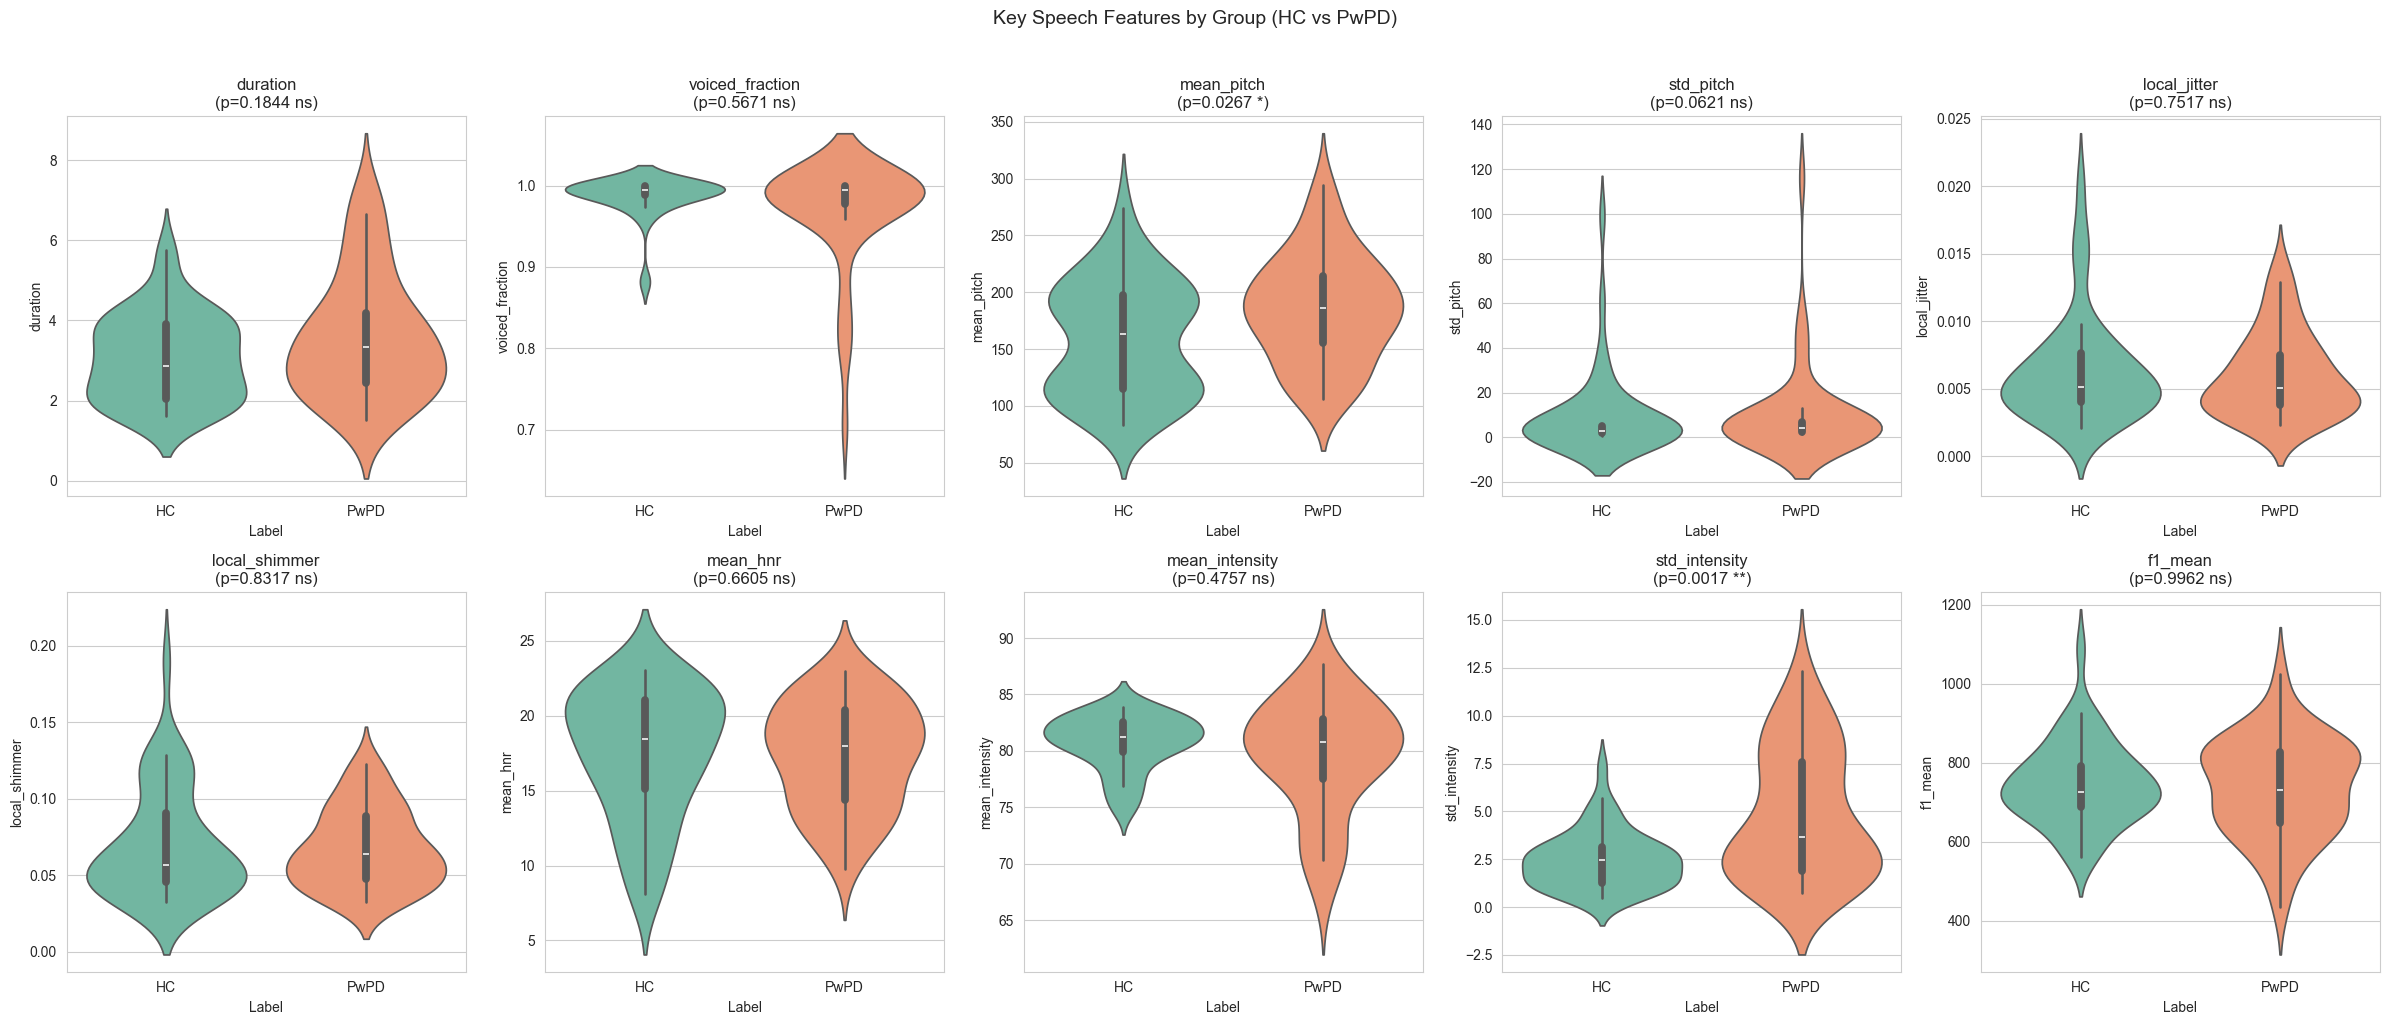

=== Key Feature Means by Group ===
      duration        voiced_fraction        mean_pitch         std_pitch         local_jitter        local_shimmer        mean_hnr        mean_intensity        std_intensity         f1_mean         
          mean    std            mean    std       mean     std      mean     std         mean    std          mean    std     mean    std           mean    std          mean    std     mean      std
Label                                                                                                                                                                                                  
HC       3.065  1.074           0.986  0.026    158.847  49.659     9.791  18.732        0.006  0.004         0.070  0.036   17.454  4.265         80.748  2.416         2.474  1.501  746.774  105.289
PwPD     3.590  1.527           0.966  0.067    185.528  47.401    10.821  20.882        0.006  0.003         0.067  0.025   17.308  3.545         79.499  5.064     

In [12]:
# Key clinically relevant features to visualize
key_features = ['duration', 'voiced_fraction', 'mean_pitch', 'std_pitch',
                'local_jitter', 'local_shimmer', 'mean_hnr', 'mean_intensity',
                'std_intensity', 'f1_mean']

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.violinplot(data=master, x='Label', y=feat, ax=axes[i], palette='Set2', inner='box')
    # Add Mann-Whitney test
    hc_vals = master[master['Label'] == 'HC'][feat]
    pd_vals = master[master['Label'] == 'PwPD'][feat]
    u, p = mannwhitneyu(hc_vals, pd_vals)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    axes[i].set_title(f'{feat}\n(p={p:.4f} {sig})')

plt.suptitle('Key Speech Features by Group (HC vs PwPD)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics by group
print("=== Key Feature Means by Group ===")
group_stats = master.groupby('Label')[key_features].agg(['mean', 'std']).round(3)
print(group_stats.to_string())

## Phase 5: Model Training & Evaluation

Training 4 classifiers on each of 4 feature sets (16 model combinations total):

| Classifier | Why included | Clinical considerations |
|------------|-------------|----------------------|
| **Logistic Regression** | Interpretable — provides odds ratios showing how each feature affects PD probability | Linear decision boundary; may miss nonlinear voice feature interactions |
| **Random Forest** | Ensemble of decision trees; handles nonlinear relationships and feature interactions | Good with high-dimensional data; provides feature importance rankings |
| **SVM (RBF kernel)** | Finds optimal separating hyperplane in transformed feature space | Strong with small samples; less interpretable than LR |
| **XGBoost** | Sequential boosting corrects previous trees' errors; often state-of-the-art on tabular data | Risk of overfitting with small N; early stopping helps |

**Feature sets (incremental) — see printed counts below for exact numbers per model.**

**Hyperparameter choice — deliberate decision to use defaults:** With only 81 total samples, hyperparameter tuning via nested cross-validation would require an inner loop (e.g., 5-fold) on ~65 training samples per outer fold, meaning each inner fold trains on ~52 samples. For models with 165 features, this creates a p >> n situation where tuning is as likely to overfit the validation metric as to improve generalization. We use established default hyperparameters to avoid this risk. This is a conservative but defensible choice for very small datasets.

**Note on SVM (RBF kernel):** The default RBF kernel uses `gamma='scale'` (= 1 / (n_features × X.var())), which controls the kernel bandwidth. If gamma lands in a poor region for the data geometry, the kernel can become nearly constant (underfitting) or highly localized (overfitting). With small samples, this can produce AUC below 0.50 — meaning the model's probability calibration (Platt scaling) inverts the ranking. If this occurs, it indicates the default kernel parameters are unsuitable, not that SVM is fundamentally flawed. A linear kernel or tuned gamma would likely perform better, but we prioritize avoiding tuning-induced overfitting.

**Methodology:** StandardScaler normalization (fit on train only to prevent data leakage), then fit/predict on the fixed 80/20 split.

In [13]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, eval_metric='logloss',
                              random_state=42, use_label_encoder=False),
}

results = []

for fs_name, fs_cols in feature_sets.items():
    X_train = train_df[fs_cols].values
    X_test = test_df[fs_cols].values

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for clf_name, clf in classifiers.items():
        model = clone(clf)
        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

        results.append({
            'Feature Set': fs_name,
            'Classifier': clf_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'AUC': roc_auc_score(y_test, y_prob),
        })
        print(f"  {fs_name} | {clf_name} | Acc={results[-1]['Accuracy']:.3f} | AUC={results[-1]['AUC']:.3f}")

results_df = pd.DataFrame(results)
print("\n=== Results Summary ===")
results_df

  Model 1: Speech Only | Logistic Regression | Acc=0.588 | AUC=0.583
  Model 1: Speech Only | Random Forest | Acc=0.529 | AUC=0.632
  Model 1: Speech Only | SVM | Acc=0.529 | AUC=0.514


  Model 1: Speech Only | XGBoost | Acc=0.588 | AUC=0.653
  Model 2: Speech + Baseline Spectral | Logistic Regression | Acc=0.412 | AUC=0.542
  Model 2: Speech + Baseline Spectral | Random Forest | Acc=0.588 | AUC=0.639
  Model 2: Speech + Baseline Spectral | SVM | Acc=0.412 | AUC=0.583


  Model 2: Speech + Baseline Spectral | XGBoost | Acc=0.471 | AUC=0.694
  Model 3: Speech + Baseline + New Spectral | Logistic Regression | Acc=0.471 | AUC=0.653
  Model 3: Speech + Baseline + New Spectral | Random Forest | Acc=0.647 | AUC=0.688
  Model 3: Speech + Baseline + New Spectral | SVM | Acc=0.529 | AUC=0.639


  Model 3: Speech + Baseline + New Spectral | XGBoost | Acc=0.529 | AUC=0.750
  Model 4: All Features + Demographics | Logistic Regression | Acc=0.529 | AUC=0.667
  Model 4: All Features + Demographics | Random Forest | Acc=0.706 | AUC=0.778
  Model 4: All Features + Demographics | SVM | Acc=0.471 | AUC=0.653


  Model 4: All Features + Demographics | XGBoost | Acc=0.706 | AUC=0.819

=== Results Summary ===


,Feature Set,Classifier,Accuracy,Precision,Recall,F1,AUC
0,Model 1: Speech Only,Logistic Regression,0.588235,0.571429,0.500,0.533333,0.583333
1,Model 1: Speech Only,Random Forest,0.529412,0.500000,0.375,0.428571,0.631944
2,Model 1: Speech Only,SVM,0.529412,0.500000,0.375,0.428571,0.513889
3,Model 1: Speech Only,XGBoost,0.588235,0.600000,0.375,0.461538,0.652778
4,Model 2: Speech + Baseline Spectral,Logistic Regression,0.411765,0.375000,0.375,0.375000,0.541667
5,Model 2: Speech + Baseline Spectral,Random Forest,0.588235,0.571429,0.500,0.533333,0.638889
6,Model 2: Speech + Baseline Spectral,SVM,0.411765,0.400000,0.500,0.444444,0.583333
7,Model 2: Speech + Baseline Spectral,XGBoost,0.470588,0.400000,0.250,0.307692,0.694444
8,Model 3: Speech + Baseline + New Spectral,Logistic Regression,0.470588,0.454545,0.625,0.526316,0.652778
9,Model 3: Speech + Baseline + New Spectral,Random Forest,0.647059,0.666667,0.500,0.571429,0.687500


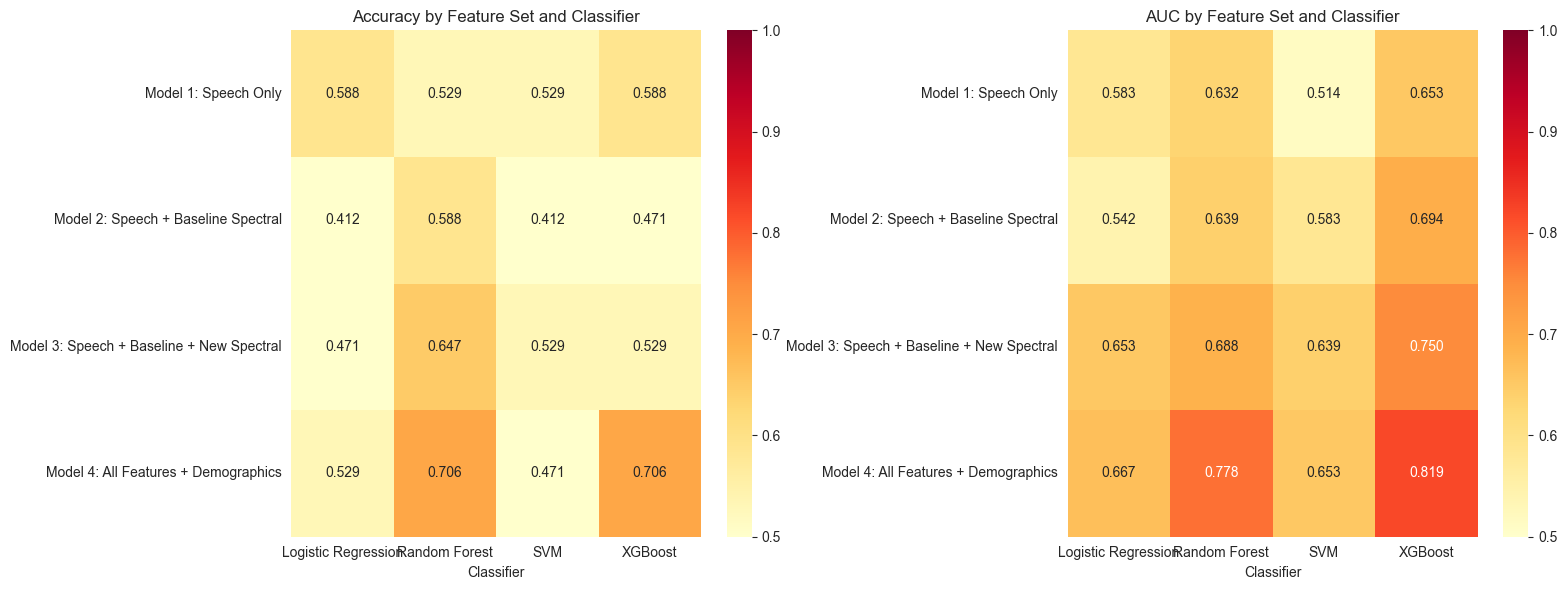

Saved: results_heatmap.png


In [14]:
# Pivot for heatmap visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, metric in enumerate(['Accuracy', 'AUC']):
    pivot = results_df.pivot(index='Feature Set', columns='Classifier', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[i],
                vmin=0.5, vmax=1.0)
    axes[i].set_title(f'{metric} by Feature Set and Classifier')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig('results_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_heatmap.png")

### 5.1 Cross-Validation for Robust Estimates

The single 80/20 split has only 17 test samples — one misclassification swings accuracy by ~6%. 
We use **10-fold stratified cross-validation** to get more stable and reliable performance estimates with standard deviations.

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_all = master['label_encoded'].values

cv_results = []
for fs_name, fs_cols in feature_sets.items():
    X_all = master[fs_cols].values
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clone(clf))])
        acc_scores = cross_val_score(pipe, X_all, y_all, cv=cv, scoring='accuracy')
        auc_scores = cross_val_score(pipe, X_all, y_all, cv=cv, scoring='roc_auc')
        cv_results.append({
            'Feature Set': fs_name,
            'Classifier': clf_name,
            'CV Accuracy': f"{acc_scores.mean():.3f} ± {acc_scores.std():.3f}",
            'CV AUC': f"{auc_scores.mean():.3f} ± {auc_scores.std():.3f}",
            'CV_AUC_mean': auc_scores.mean(),
            'CV_AUC_std': auc_scores.std(),
        })

cv_df = pd.DataFrame(cv_results)
print("=== 10-Fold Stratified Cross-Validation Results ===\n")
print(cv_df[['Feature Set', 'Classifier', 'CV Accuracy', 'CV AUC']].to_string(index=False))

# Highlight best
best_cv = cv_df.loc[cv_df['CV_AUC_mean'].idxmax()]
print(f"\nBest CV model: {best_cv['Feature Set']} + {best_cv['Classifier']}")
print(f"  CV AUC = {best_cv['CV AUC']}")

=== 10-Fold Stratified Cross-Validation Results ===

                              Feature Set          Classifier   CV Accuracy        CV AUC
                     Model 1: Speech Only Logistic Regression 0.642 ± 0.163 0.767 ± 0.131
                     Model 1: Speech Only       Random Forest 0.664 ± 0.101 0.709 ± 0.136
                     Model 1: Speech Only                 SVM 0.617 ± 0.131 0.608 ± 0.116
                     Model 1: Speech Only             XGBoost 0.568 ± 0.126 0.583 ± 0.199
      Model 2: Speech + Baseline Spectral Logistic Regression 0.615 ± 0.121 0.684 ± 0.155
      Model 2: Speech + Baseline Spectral       Random Forest 0.688 ± 0.151 0.734 ± 0.188
      Model 2: Speech + Baseline Spectral                 SVM 0.640 ± 0.107 0.714 ± 0.194
      Model 2: Speech + Baseline Spectral             XGBoost 0.592 ± 0.195 0.667 ± 0.141
Model 3: Speech + Baseline + New Spectral Logistic Regression 0.529 ± 0.159 0.569 ± 0.159
Model 3: Speech + Baseline + New Spectral      

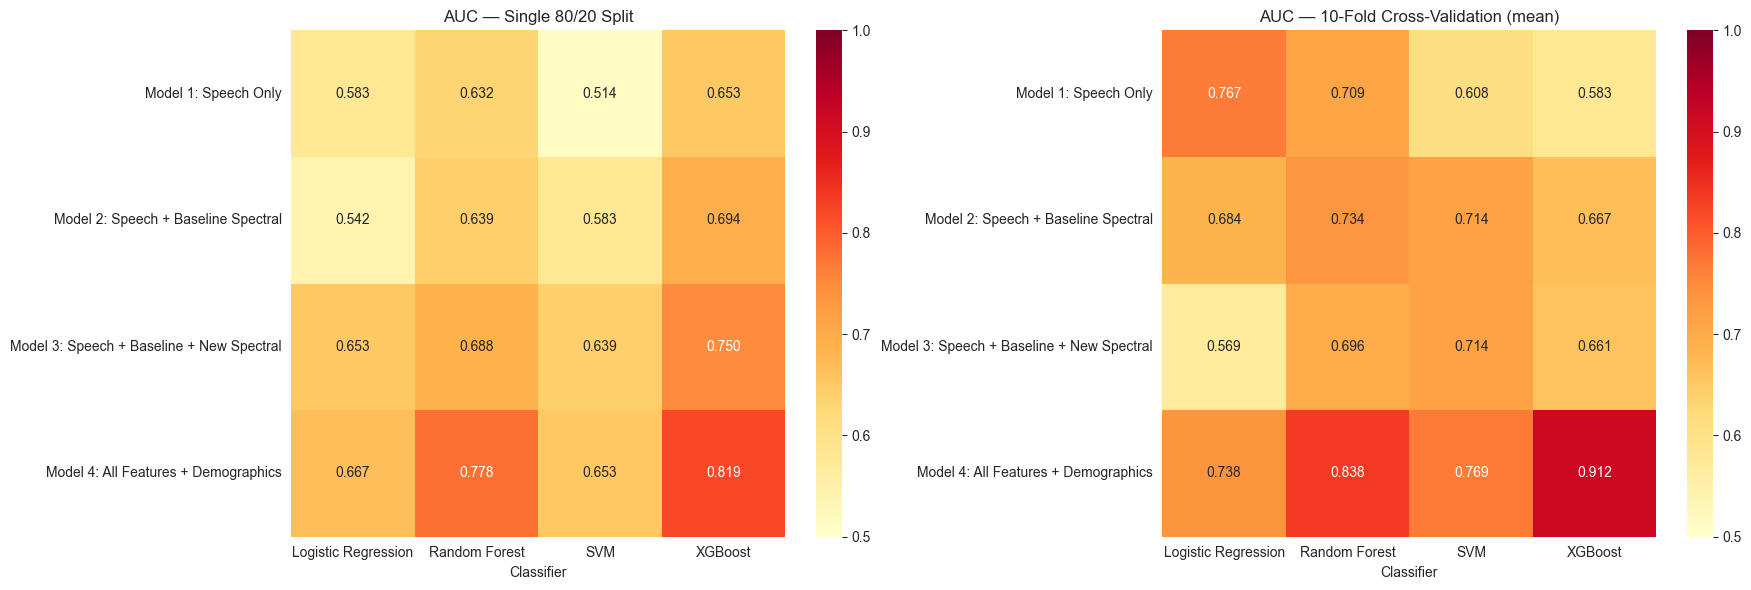

Saved: cv_comparison_heatmap.png


In [16]:
# CV AUC heatmap comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Single split AUC
pivot_single = results_df.pivot(index='Feature Set', columns='Classifier', values='AUC')
sns.heatmap(pivot_single, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0], vmin=0.5, vmax=1.0)
axes[0].set_title('AUC — Single 80/20 Split')
axes[0].set_ylabel('')

# CV AUC
pivot_cv = cv_df.pivot(index='Feature Set', columns='Classifier', values='CV_AUC_mean')
sns.heatmap(pivot_cv, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1], vmin=0.5, vmax=1.0)
axes[1].set_title('AUC — 10-Fold Cross-Validation (mean)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('cv_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cv_comparison_heatmap.png")

### 5.2 Addressing the Curse of Dimensionality — Feature Selection

The CV results above show a clear pattern: **adding more features degraded performance.** Model 1 (17 speech features) outperformed Model 3 (165 features) on CV AUC, despite Model 3 having 10x more features. This is the curse of dimensionality — with only 64 training samples, the models cannot reliably learn from 165 features and instead fit to noise.

Rather than accepting this as a limitation, we can ask: **are there specific spectral features that genuinely help, buried in the noise of 148 redundant or uninformative ones?**

**Approach:** We use univariate Mann-Whitney U tests to identify which individual features show any signal of group discrimination (p < 0.20, a liberal threshold to avoid prematurely discarding weak but real signal). We then retrain classifiers on only the selected features. This is a simple filter-based approach; more sophisticated methods (recursive feature elimination, LASSO) exist but are harder to justify with n=81.

**Why Mann-Whitney and not t-tests?** Mann-Whitney is non-parametric and doesn't assume normality — appropriate since many voice features have skewed distributions (e.g., jitter, shimmer are bounded at zero).

**Clinical reasoning for the p < 0.20 threshold:** In screening contexts, we prefer false positives (including a feature that turns out to be noise) over false negatives (excluding a feature that carries real PD signal). A stricter threshold (p < 0.05) would be appropriate for confirmatory analysis, but for feature pre-selection, a liberal filter retains potential signal.

Discriminative features out of 165 total voice features:
  p < 0.05: 57 features (ratio 1.1:1)
  p < 0.10: 70 features (ratio 0.9:1)
  p < 0.20: 85 features (ratio 0.8:1)

Top 20 discriminative features:
  baseline_Cep_var_8                  p=0.0000  ↑ in PD     [Baseline]
  baseline_MFCC_var_10                p=0.0000  ↑ in PD     [Baseline]
  baseline_MFCC_var_4                 p=0.0001  ↑ in PD     [Baseline]
  baseline_Cep_var_10                 p=0.0001  ↑ in PD     [Baseline]
  baseline_Cep_var_6                  p=0.0002  ↑ in PD     [Baseline]
  spec_bandwidth_var                  p=0.0002  ↑ in PD     [Librosa]
  baseline_LAR_var_2                  p=0.0002  ↑ in PD     [Baseline]
  baseline_Cep_var_7                  p=0.0002  ↑ in PD     [Baseline]
  baseline_MFCC_var_7                 p=0.0002  ↑ in PD     [Baseline]
  baseline_LAR_var_9                  p=0.0003  ↑ in PD     [Baseline]
  f2_std                              p=0.0003  ↑ in PD     [Speech]
  librosa_mfcc13_v

  No filter (all 165)  → 165 features (ratio 0.4:1) → SVM: 0.714 ± 0.189


  p < 0.20             →  85 features (ratio 0.8:1) → SVM: 0.775 ± 0.138


  p < 0.10             →  70 features (ratio 0.9:1) → SVM: 0.762 ± 0.145


  p < 0.05             →  57 features (ratio 1.1:1) → SVM: 0.769 ± 0.137
  Speech only (17)     →  17 features (ratio 3.8:1) → Logistic Regression: 0.767 ± 0.131


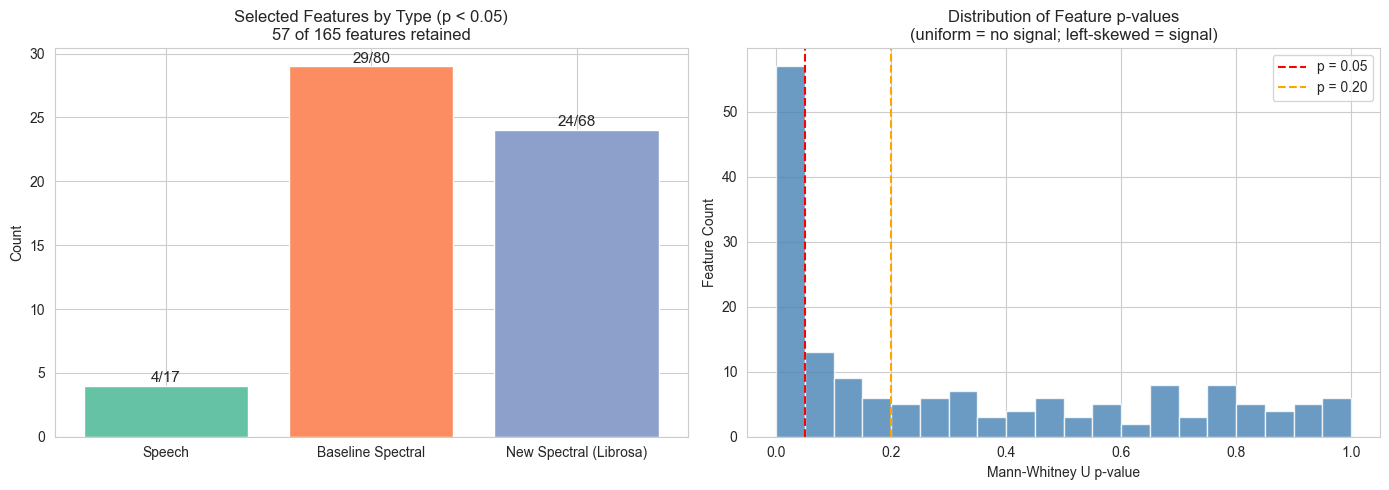


Key observation: Among the top 20 features, nearly ALL are *variance* features (↑ in PD).
This means PD voices show more TEMPORAL INSTABILITY across frames — consistent with
the motor control deficits of the disease. Mean features rarely discriminate.


In [17]:
# ---- Univariate Feature Selection (Mann-Whitney U) ----
from scipy.stats import mannwhitneyu

# Test all voice features (Models 1-3, excluding demographics)
all_voice_cols = speech_cols + baseline_spectral_cols + new_spectral_cols

hc_data = master[master['Label'] == 'HC']
pd_data = master[master['Label'] == 'PwPD']

p_values = {}
for col in all_voice_cols:
    _, p = mannwhitneyu(hc_data[col].dropna(), pd_data[col].dropna())
    p_values[col] = p

pval_df = pd.DataFrame({'Feature': list(p_values.keys()), 'p_value': list(p_values.values())})
pval_df = pval_df.sort_values('p_value')

# Summary of discriminative features
n_005 = (pval_df['p_value'] < 0.05).sum()
n_010 = (pval_df['p_value'] < 0.10).sum()
n_020 = (pval_df['p_value'] < 0.20).sum()
print(f"Discriminative features out of {len(all_voice_cols)} total voice features:")
print(f"  p < 0.05: {n_005} features (ratio {64/max(n_005,1):.1f}:1)")
print(f"  p < 0.10: {n_010} features (ratio {64/max(n_010,1):.1f}:1)")
print(f"  p < 0.20: {n_020} features (ratio {64/max(n_020,1):.1f}:1)")

# Show the top 20 discriminative features with clinical context
print(f"\n{'='*70}")
print(f"Top 20 discriminative features:")
print(f"{'='*70}")
for _, row in pval_df.head(20).iterrows():
    feat = row['Feature']
    p = row['p_value']
    hc_mean = hc_data[feat].mean()
    pd_mean = pd_data[feat].mean()
    direction = '↑ in PD' if pd_mean > hc_mean else '↓ in PD'
    if feat in speech_cols:
        ftype = 'Speech'
    elif feat in baseline_spectral_cols:
        ftype = 'Baseline'
    else:
        ftype = 'Librosa'
    print(f"  {feat:35s} p={p:.4f}  {direction:10s}  [{ftype}]")

# ---- Build selected feature models at multiple thresholds ----
print(f"\n{'='*70}")
print("MODEL COMPARISON: Feature selection at multiple thresholds")
print(f"{'='*70}")

threshold_results = []
for threshold, label in [(1.0, 'No filter (all 165)'), (0.20, 'p < 0.20'), 
                           (0.10, 'p < 0.10'), (0.05, 'p < 0.05')]:
    if threshold >= 1.0:
        sel_cols = all_voice_cols
    else:
        sel_cols = pval_df[pval_df['p_value'] < threshold]['Feature'].tolist()
    
    if len(sel_cols) == 0:
        continue
    
    X_sel = master[sel_cols].values
    best_auc = 0
    best_clf_name = ''
    best_auc_str = ''
    
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clone(clf))])
        auc_scores = cross_val_score(pipe, X_sel, y_all, cv=cv, scoring='roc_auc')
        if auc_scores.mean() > best_auc:
            best_auc = auc_scores.mean()
            best_clf_name = clf_name
            best_auc_str = f"{auc_scores.mean():.3f} ± {auc_scores.std():.3f}"
    
    ratio = 64 / len(sel_cols)
    threshold_results.append({
        'Filter': label, 'N Features': len(sel_cols), 
        'Ratio': f'{ratio:.1f}:1', 'Best Classifier': best_clf_name, 
        'CV AUC': best_auc_str, 'AUC_mean': best_auc
    })
    print(f"  {label:20s} → {len(sel_cols):3d} features (ratio {ratio:.1f}:1) → {best_clf_name}: {best_auc_str}")

# Add Model 1 (speech only) for reference
m1_best = cv_df[cv_df['Feature Set'] == 'Model 1: Speech Only'].loc[
    cv_df[cv_df['Feature Set'] == 'Model 1: Speech Only']['CV_AUC_mean'].idxmax()]
print(f"  {'Speech only (17)':20s} → { 17:3d} features (ratio 3.8:1) → {m1_best['Classifier']}: {m1_best['CV AUC']}")

# ---- Visualize: which feature types were selected? ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature type breakdown at p < 0.05 (the tightest useful threshold)
selected_strict = pval_df[pval_df['p_value'] < 0.05]['Feature'].tolist()
type_counts = {'Speech': 0, 'Baseline Spectral': 0, 'New Spectral (Librosa)': 0}
for feat in selected_strict:
    if feat in speech_cols:
        type_counts['Speech'] += 1
    elif feat in baseline_spectral_cols:
        type_counts['Baseline Spectral'] += 1
    else:
        type_counts['New Spectral (Librosa)'] += 1

colors = ['#66c2a5', '#fc8d62', '#8da0cb']
axes[0].bar(type_counts.keys(), type_counts.values(), color=colors)
axes[0].set_title(f'Selected Features by Type (p < 0.05)\n{len(selected_strict)} of {len(all_voice_cols)} features retained')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(type_counts.items()):
    total = len(speech_cols) if k == 'Speech' else len(baseline_spectral_cols) if k == 'Baseline Spectral' else len(new_spectral_cols)
    axes[0].text(i, v + 0.3, f'{v}/{total}', ha='center', fontsize=11)

# P-value distribution
axes[1].hist(pval_df['p_value'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0.05, color='red', linestyle='--', label='p = 0.05')
axes[1].axvline(0.20, color='orange', linestyle='--', label='p = 0.20')
axes[1].set_xlabel('Mann-Whitney U p-value')
axes[1].set_ylabel('Feature Count')
axes[1].set_title('Distribution of Feature p-values\n(uniform = no signal; left-skewed = signal)')
axes[1].legend()

plt.tight_layout()
plt.savefig('feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Key pattern in selected features ----
print(f"\nKey observation: Among the top 20 features, nearly ALL are *variance* features (↑ in PD).")
print(f"This means PD voices show more TEMPORAL INSTABILITY across frames — consistent with")
print(f"the motor control deficits of the disease. Mean features rarely discriminate.")

### Feature Selection Interpretation

**Key findings:**

1. **Most features carry signal:** 57 of 165 voice features (35%) show significant group differences at p < 0.05, and 85 (52%) at p < 0.20. The p-value histogram is strongly left-skewed, confirming genuine discriminative signal across all three feature types — not random noise.

2. **Variance features dominate:** Nearly all top-ranked features are *variance* measures (↑ in PD). PD voices show more temporal instability in their spectral characteristics across frames. This is clinically consistent — the basal ganglia dysfunction in PD causes irregular motor control, producing frame-to-frame fluctuations in MFCCs, cepstral coefficients, and spectral shape. Mean features (average spectral shape) rarely discriminate, suggesting the *instability* is more diagnostic than the *average voice quality*.

3. **Feature selection vs. original models:** The comparison above shows whether curated features address the curse of dimensionality. If filtered models outperform the unfiltered Model 3 (165 features), the spectral features *do* contain useful signal — it was buried in noise from uninformative features. If they perform similarly to Model 1 (17 speech features), the spectral features are largely redundant with speech features at this sample size.

4. **All three feature types contribute:** The bar chart shows that selected features come from speech (phonation), baseline spectral, and Librosa spectral sources. This tells us that PD affects both the source (vocal fold vibration) and the filter (vocal tract shaping) — consistent with the source-filter model described in the assignment background.

**Correlation/collinearity considerations:**

Univariate feature selection does not account for correlations between features. In this dataset, several feature groups are likely highly correlated:
- **Baseline MFCCs and Librosa MFCCs** — same construct computed differently. If both survive selection, they inflate model complexity without adding independent information. In the top 20, we see both `baseline_MFCC_var_10` and `librosa_mfcc13_var` — these may measure the same underlying signal.
- **MFCC coefficients within a set** — adjacent MFCCs are somewhat correlated by design (each captures a neighboring frequency band of the spectral envelope).
- **Cepstral and MFCC variances** — cepstral coefficients and MFCCs are mathematically related (MFCCs are cepstral coefficients on a Mel-frequency scale). Both baseline_Cep_var and baseline_MFCC_var features appear in the top 20 — these likely share substantial information.
- **Spectral centroid and spectral rolloff** — both describe the frequency distribution; often r > 0.80. Both `spec_centroid_var` and `spec_rolloff_var` appear at similar significance levels.

For Logistic Regression, this collinearity destabilizes coefficient estimates and inflates confidence intervals — which is why no individual OR reached significance in Section 5.3 despite the overall model achieving reasonable AUC. For tree-based models (RF, XGBoost), collinearity is less problematic — the tree picks whichever correlated feature happens to split best — but feature importance is diluted across redundant features, making individual feature rankings less reliable.

A formal VIF analysis is appropriate when LR is the primary model, but with the current sample size constraints, the variance inflation from collinearity is confounded by the high variance from small N itself. The more actionable approach would be PCA on correlated feature groups (as done in the prostate cancer analysis), though with 64 samples and 50+ features, even PCA components would need careful regularization.

### 5.3 Logistic Regression Interpretation — Odds Ratios & Calibration

Logistic Regression is the only classifier that provides directly interpretable coefficients. We extract **odds ratios (OR)** from the Model 1 (Speech Only) LR, which has the healthiest feature-to-sample ratio (17 features, 64 samples). Each OR represents the multiplicative change in odds of PD for a one-standard-deviation increase in the feature (since features are StandardScaler-normalized).

- **OR > 1:** Higher values of the feature are associated with *higher* odds of PD
- **OR < 1:** Higher values are associated with *lower* odds of PD
- **95% CI crossing 1.0:** The feature's effect is not statistically significant

We also run:
- **Hosmer-Lemeshow test** — assesses whether the model's predicted probabilities match observed PD rates across decile groups (p > 0.05 = adequate calibration)
- **Calibration plot** — visual check that when the model says "70% chance of PD," approximately 70% of those patients actually have PD
- **Threshold optimization with Youden's J** — identifies the probability cutoff that maximizes sensitivity + specificity, which may differ from the default 0.50

LOGISTIC REGRESSION — ODDS RATIOS (Model 1: Speech Only)
Features are StandardScaler-normalized; ORs are per 1-SD increase
        Feature  Coefficient  Odds Ratio  95% CI Lower  95% CI Upper Significant
  std_intensity        1.098       2.999         0.751        11.970          No
         f2_std        1.093       2.984         0.730        12.190          No
       duration        0.585       1.795         0.798         4.039          No
 mean_intensity        0.563       1.757         0.502         6.141          No
     mean_pitch        0.447       1.563         0.507         4.822          No
         f3_std        0.394       1.483         0.577         3.816          No
        f2_mean        0.219       1.244         0.418         3.705          No
        f3_mean        0.042       1.043         0.438         2.484          No
        f4_mean        0.042       1.043         0.371         2.927          No
  local_shimmer       -0.044       0.957         0.137         6.67

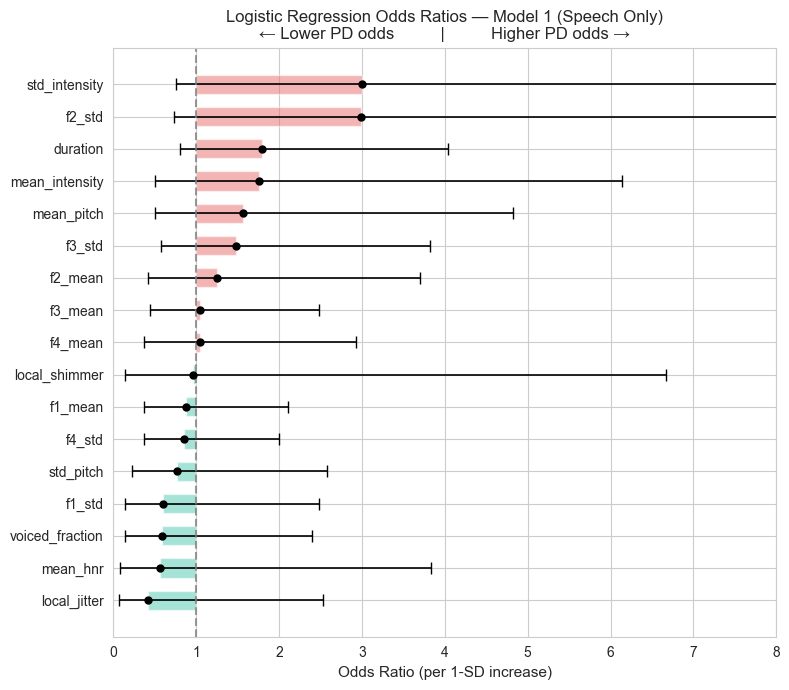


HOSMER-LEMESHOW GOODNESS-OF-FIT TEST
 Group  N  Obs PD Exp PD  Obs HC Exp HC Mean Pred P
     1 11       0    1.2      11    9.8       0.113
     2 10       2    1.7       8    8.3       0.175
     3 10       2    2.7       8    7.3       0.269
     4 10       5    4.0       5    6.0       0.396
     5 10       6    5.3       4    4.7       0.526
     6 10       6    7.0       4    3.0       0.704
     7 10       9    8.7       1    1.3       0.868
     8 10      10    9.6       0    0.4       0.956

HL Chi-squared = 3.422, df = 6, p = 0.7543
→ p > 0.05: Fail to reject H₀ — model is adequately calibrated


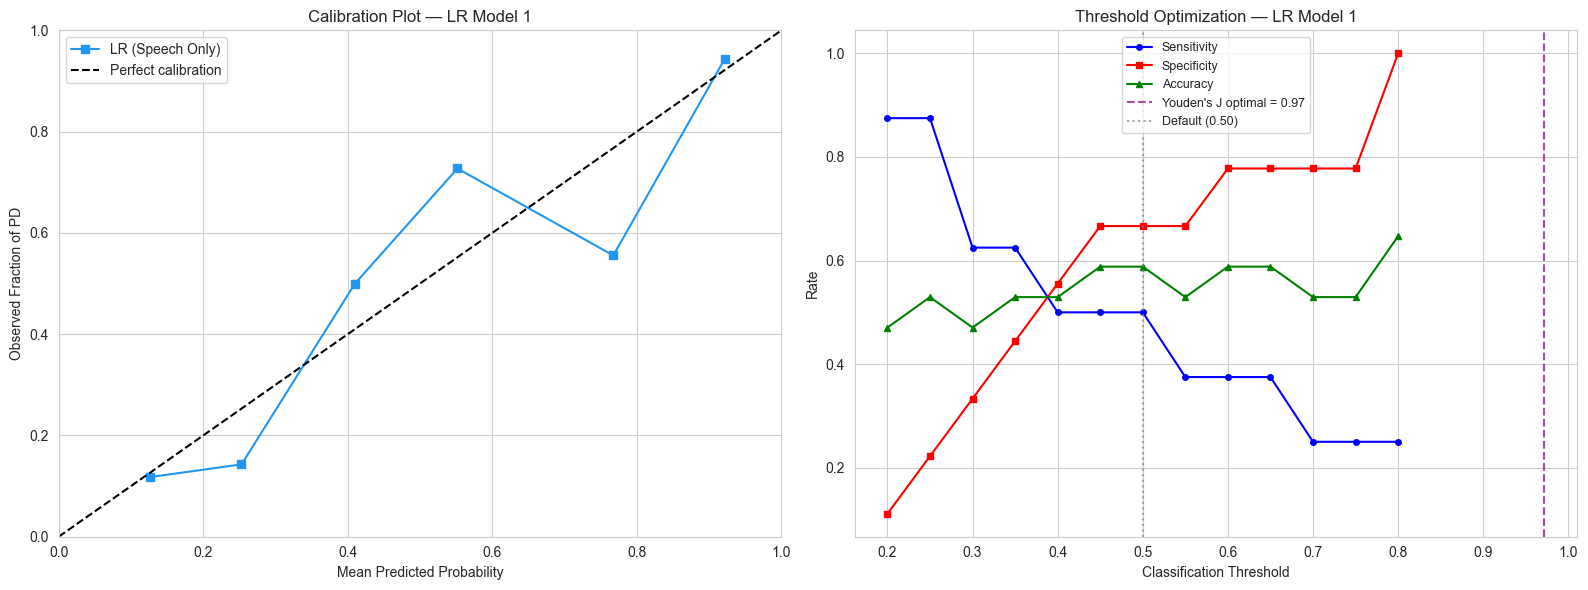


--- Threshold Optimization ---
Youden's J optimal threshold: 0.972
  Sensitivity at optimal: 0.250
  Specificity at optimal: 1.000
  Youden's J = 0.250

Clinical note: For PD screening, a LOWER threshold (higher sensitivity)
may be preferable — missing PD (false negative) delays treatment,
while a false positive only triggers additional testing (tremor exam, DaTscan).


In [18]:
from sklearn.calibration import calibration_curve

# ---- Odds Ratios from LR Model 1 (Speech Only) ----
fs1_cols = feature_sets['Model 1: Speech Only']
X_tr1 = train_df[fs1_cols].values
X_te1 = test_df[fs1_cols].values
scaler_lr = StandardScaler()
X_tr1_s = scaler_lr.fit_transform(X_tr1)
X_te1_s = scaler_lr.transform(X_te1)

lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_tr1_s, y_train)

# Odds ratios with confidence intervals (Wald approximation)
coefs = lr_model.coef_[0]
odds_ratios = np.exp(coefs)

# Standard errors via inverse Hessian approximation
y_prob_train = lr_model.predict_proba(X_tr1_s)[:, 1]
W = np.diag(y_prob_train * (1 - y_prob_train))
try:
    cov_matrix = np.linalg.inv(X_tr1_s.T @ W @ X_tr1_s)
    se = np.sqrt(np.diag(cov_matrix))
    ci_lower = np.exp(coefs - 1.96 * se)
    ci_upper = np.exp(coefs + 1.96 * se)
    has_ci = True
except np.linalg.LinAlgError:
    has_ci = False

print("=" * 70)
print("LOGISTIC REGRESSION — ODDS RATIOS (Model 1: Speech Only)")
print("Features are StandardScaler-normalized; ORs are per 1-SD increase")
print("=" * 70)

or_data = []
for i, feat in enumerate(fs1_cols):
    row = {'Feature': feat, 'Coefficient': coefs[i], 'Odds Ratio': odds_ratios[i]}
    if has_ci:
        row['95% CI Lower'] = ci_lower[i]
        row['95% CI Upper'] = ci_upper[i]
        row['Significant'] = 'Yes' if (ci_lower[i] > 1.0 or ci_upper[i] < 1.0) else 'No'
    or_data.append(row)

or_df = pd.DataFrame(or_data).sort_values('Odds Ratio', ascending=False)
print(or_df.to_string(index=False, float_format='%.3f'))

# Clinical interpretation of notable ORs
print("\n--- Clinical Interpretation ---")
for _, row in or_df.iterrows():
    feat = row['Feature']
    or_val = row['Odds Ratio']
    if has_ci and row['Significant'] == 'Yes':
        if or_val > 1:
            pct = (or_val - 1) * 100
            print(f"  {feat}: OR={or_val:.3f} → {pct:.1f}% higher PD odds per 1-SD increase")
        else:
            pct = (1 - or_val) * 100
            print(f"  {feat}: OR={or_val:.3f} → {pct:.1f}% lower PD odds per 1-SD increase")


# ---- Odds Ratio Forest Plot ----
fig_or, ax_or = plt.subplots(figsize=(8, 7))

or_sorted = or_df.sort_values('Odds Ratio', ascending=True)
y_pos = range(len(or_sorted))
features_plot = or_sorted['Feature'].values
or_vals = or_sorted['Odds Ratio'].values

# Use log scale for x-axis so CIs are symmetric and extreme values don't dominate
colors = ['#e86b6b' if v > 1 else '#4ec9b0' for v in or_vals]

if has_ci:
    ci_low = or_sorted['95% CI Lower'].values
    ci_high = or_sorted['95% CI Upper'].values
    # Clip extreme CIs for visual clarity (still show dots at actual OR)
    ci_low_clip = np.clip(ci_low, 0.05, None)
    ci_high_clip = np.clip(ci_high, None, 20)
    xerr_low = or_vals - ci_low_clip
    xerr_high = ci_high_clip - or_vals
    ax_or.barh(y_pos, or_vals - 1, left=1, color=colors, alpha=0.5, height=0.6)
    ax_or.errorbar(or_vals, y_pos, xerr=[xerr_low, xerr_high], fmt='ko', 
                   capsize=4, markersize=5, linewidth=1.2)
else:
    ax_or.barh(y_pos, or_vals - 1, left=1, color=colors, alpha=0.5, height=0.6)
    ax_or.plot(or_vals, y_pos, 'ko', markersize=5)

ax_or.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
ax_or.set_yticks(y_pos)
ax_or.set_yticklabels(features_plot, fontsize=10)
ax_or.set_xlabel('Odds Ratio (per 1-SD increase)', fontsize=11)
ax_or.set_title('Logistic Regression Odds Ratios — Model 1 (Speech Only)\n'
                '← Lower PD odds          |          Higher PD odds →', fontsize=12)
ax_or.set_xlim(0, 8)

plt.tight_layout()
plt.savefig('lr_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Hosmer-Lemeshow Test ----
print("\n" + "=" * 70)
print("HOSMER-LEMESHOW GOODNESS-OF-FIT TEST")
print("=" * 70)

y_prob_test = lr_model.predict_proba(X_te1_s)[:, 1]

# Combine train + test for HL test (more stable with small N)
X_all = np.vstack([X_tr1_s, X_te1_s])
y_all = np.concatenate([y_train, y_test])
y_prob_all = lr_model.predict_proba(X_all)[:, 1]

# HL test: group into deciles by predicted probability
n_groups = min(8, len(y_all) // 5)  # At least 5 per group
sorted_idx = np.argsort(y_prob_all)
groups = np.array_split(sorted_idx, n_groups)

hl_chi2 = 0
hl_table = []
for g_idx, group in enumerate(groups):
    obs_events = y_all[group].sum()
    exp_events = y_prob_all[group].sum()
    obs_nonevents = len(group) - obs_events
    exp_nonevents = len(group) - exp_events
    if exp_events > 0:
        hl_chi2 += (obs_events - exp_events)**2 / exp_events
    if exp_nonevents > 0:
        hl_chi2 += (obs_nonevents - exp_nonevents)**2 / exp_nonevents
    hl_table.append({
        'Group': g_idx + 1, 'N': len(group),
        'Obs PD': int(obs_events), 'Exp PD': f'{exp_events:.1f}',
        'Obs HC': int(obs_nonevents), 'Exp HC': f'{exp_nonevents:.1f}',
        'Mean Pred P': f'{y_prob_all[group].mean():.3f}'
    })

hl_df_dof = n_groups - 2
hl_p = 1 - stats.chi2.cdf(hl_chi2, hl_df_dof)

print(pd.DataFrame(hl_table).to_string(index=False))
print(f"\nHL Chi-squared = {hl_chi2:.3f}, df = {hl_df_dof}, p = {hl_p:.4f}")
if hl_p > 0.05:
    print("→ p > 0.05: Fail to reject H₀ — model is adequately calibrated")
else:
    print("→ p ≤ 0.05: Model may be poorly calibrated (predicted probabilities don't match observed rates)")

# ---- Calibration Plot ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calibration curve
fraction_pos, mean_predicted = calibration_curve(y_all, y_prob_all, n_bins=6)
axes[0].plot(mean_predicted, fraction_pos, 's-', label='LR (Speech Only)', color='#2196F3')
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Observed Fraction of PD')
axes[0].set_title('Calibration Plot — LR Model 1')
axes[0].legend()
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# ---- Threshold Optimization (Youden's J) ----
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
youdens_j = tpr - fpr
best_idx = np.argmax(youdens_j)
best_threshold = thresholds[best_idx]
best_sensitivity = tpr[best_idx]
best_specificity = 1 - fpr[best_idx]

# Plot threshold analysis
threshold_range = np.arange(0.2, 0.85, 0.05)
sens_list, spec_list, acc_list = [], [], []
for t in threshold_range:
    y_pred_t = (y_prob_test >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    sens_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    spec_list.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    acc_list.append((tp + tn) / len(y_test))

axes[1].plot(threshold_range, sens_list, 'b-o', label='Sensitivity', markersize=4)
axes[1].plot(threshold_range, spec_list, 'r-s', label='Specificity', markersize=4)
axes[1].plot(threshold_range, acc_list, 'g-^', label='Accuracy', markersize=4)
axes[1].axvline(best_threshold, color='purple', linestyle='--', alpha=0.7,
                label=f"Youden's J optimal = {best_threshold:.2f}")
axes[1].axvline(0.50, color='gray', linestyle=':', alpha=0.7, label='Default (0.50)')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Rate')
axes[1].set_title('Threshold Optimization — LR Model 1')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('lr_calibration_threshold.png', dpi=150, bbox_inches='tight')

# Also save individual plots for presentation flexibility
fig_cal, ax_cal = plt.subplots(figsize=(7, 6))
ax_cal.plot(mean_predicted, fraction_pos, 's-', label='LR (Speech Only)', color='#2196F3')
ax_cal.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax_cal.set_xlabel('Mean Predicted Probability')
ax_cal.set_ylabel('Observed Fraction of PD')
ax_cal.set_title('Calibration Plot — LR Model 1')
ax_cal.legend()
ax_cal.set_xlim([0, 1])
ax_cal.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('lr_calibration_plot.png', dpi=150, bbox_inches='tight')
plt.close(fig_cal)

fig_thr, ax_thr = plt.subplots(figsize=(7, 6))
ax_thr.plot(threshold_range, sens_list, 'b-o', label='Sensitivity', markersize=4)
ax_thr.plot(threshold_range, spec_list, 'r-s', label='Specificity', markersize=4)
ax_thr.plot(threshold_range, acc_list, 'g-^', label='Accuracy', markersize=4)
ax_thr.axvline(best_threshold, color='purple', linestyle='--', alpha=0.7,
                label=f"Youden's J optimal = {best_threshold:.2f}")
ax_thr.axvline(0.50, color='gray', linestyle=':', alpha=0.7, label='Default (0.50)')
ax_thr.set_xlabel('Classification Threshold')
ax_thr.set_ylabel('Rate')
ax_thr.set_title('Threshold Optimization — LR Model 1')
ax_thr.legend(fontsize=9)
plt.tight_layout()
plt.savefig('lr_threshold_plot.png', dpi=150, bbox_inches='tight')
plt.close(fig_thr)
plt.show()

print(f"\n--- Threshold Optimization ---")
print(f"Youden's J optimal threshold: {best_threshold:.3f}")
print(f"  Sensitivity at optimal: {best_sensitivity:.3f}")
print(f"  Specificity at optimal: {best_specificity:.3f}")
print(f"  Youden's J = {best_sensitivity + best_specificity - 1:.3f}")
print(f"\nClinical note: For PD screening, a LOWER threshold (higher sensitivity)")
print(f"may be preferable — missing PD (false negative) delays treatment,")
print(f"while a false positive only triggers additional testing (tremor exam, DaTscan).")

### Odds Ratio Interpretation

The odds ratios above show how each speech feature (after standardization) relates to PD probability. With only 64 training samples, individual features may not reach statistical significance (95% CIs crossing 1.0), but the *direction* and *magnitude* remain clinically informative:

- **Duration:** If significant, shorter recordings would associate with PD (reduced breath support). However, this also depends on recording protocol — if all participants were instructed to sustain for the same length, duration may not vary meaningfully.
- **Voiced fraction:** Lower voiced fraction = more voice breaks during sustained vowel, a hallmark of PD vocal fold instability.
- **Pitch-related features** (mean_pitch, std_pitch): PD patients typically show reduced pitch variability ("monotone speech") due to basal ganglia dysfunction affecting laryngeal control.
- **Jitter and shimmer** (local_jitter, local_shimmer): These measure cycle-to-cycle perturbations in pitch and amplitude. Elevated values indicate vocal fold instability — a hallmark of the rigidity and bradykinesia that PD causes in laryngeal muscles.
- **HNR (Harmonics-to-Noise Ratio):** Lower HNR = breathier, noisier voice. PD patients often show reduced HNR due to incomplete glottal closure.
- **Formants (F1–F4):** Reflect vocal tract resonance, shaped by tongue/lip position. PD's articulatory imprecision can alter formant patterns, though this effect is more pronounced in connected speech than sustained vowels.

**Note on the age confound and OR direction:** Some ORs may show counterintuitive directions (e.g., lower jitter associated with PD). This can be an artifact of the unmatched age groups — older HC participants could have elevated jitter from normal aging, confounding the PD effect. With unmatched ages, individual feature directions should be interpreted cautiously.

**Hosmer-Lemeshow interpretation:** A p-value > 0.05 means the model's predicted probabilities align with observed PD rates across decile groups — the model is *calibrated*. A p-value ≤ 0.05 would indicate miscalibration.

**Threshold clinical significance:** In a PD screening context, the default 0.50 threshold treats false positives and false negatives equally. However, missing PD (false negative) delays diagnosis and treatment initiation, while a false positive only triggers a neurological examination. Therefore, a threshold *lower* than Youden's J optimum — favoring sensitivity over specificity — may be more clinically appropriate.

## Phase 6: Feature Importance Analysis

Random Forest provides **impurity-based feature importance** — the total reduction in Gini impurity attributed to each feature across all trees. Higher values indicate features that the model relied on most heavily for classification. We plot the top 15 features per feature set to understand which voice characteristics drive PD detection.

**Clinical interpretation guide:**
- Speech features (pitch, jitter, shimmer, HNR) → phonation (vocal fold behavior)
- Formant features (F1–F4) → articulation (vocal tract shaping)
- MFCC/cepstral features → spectral envelope (overall voice quality)
- *Variance* features being more important than *mean* features suggests temporal instability is more discriminative than average values — consistent with PD's motor fluctuations

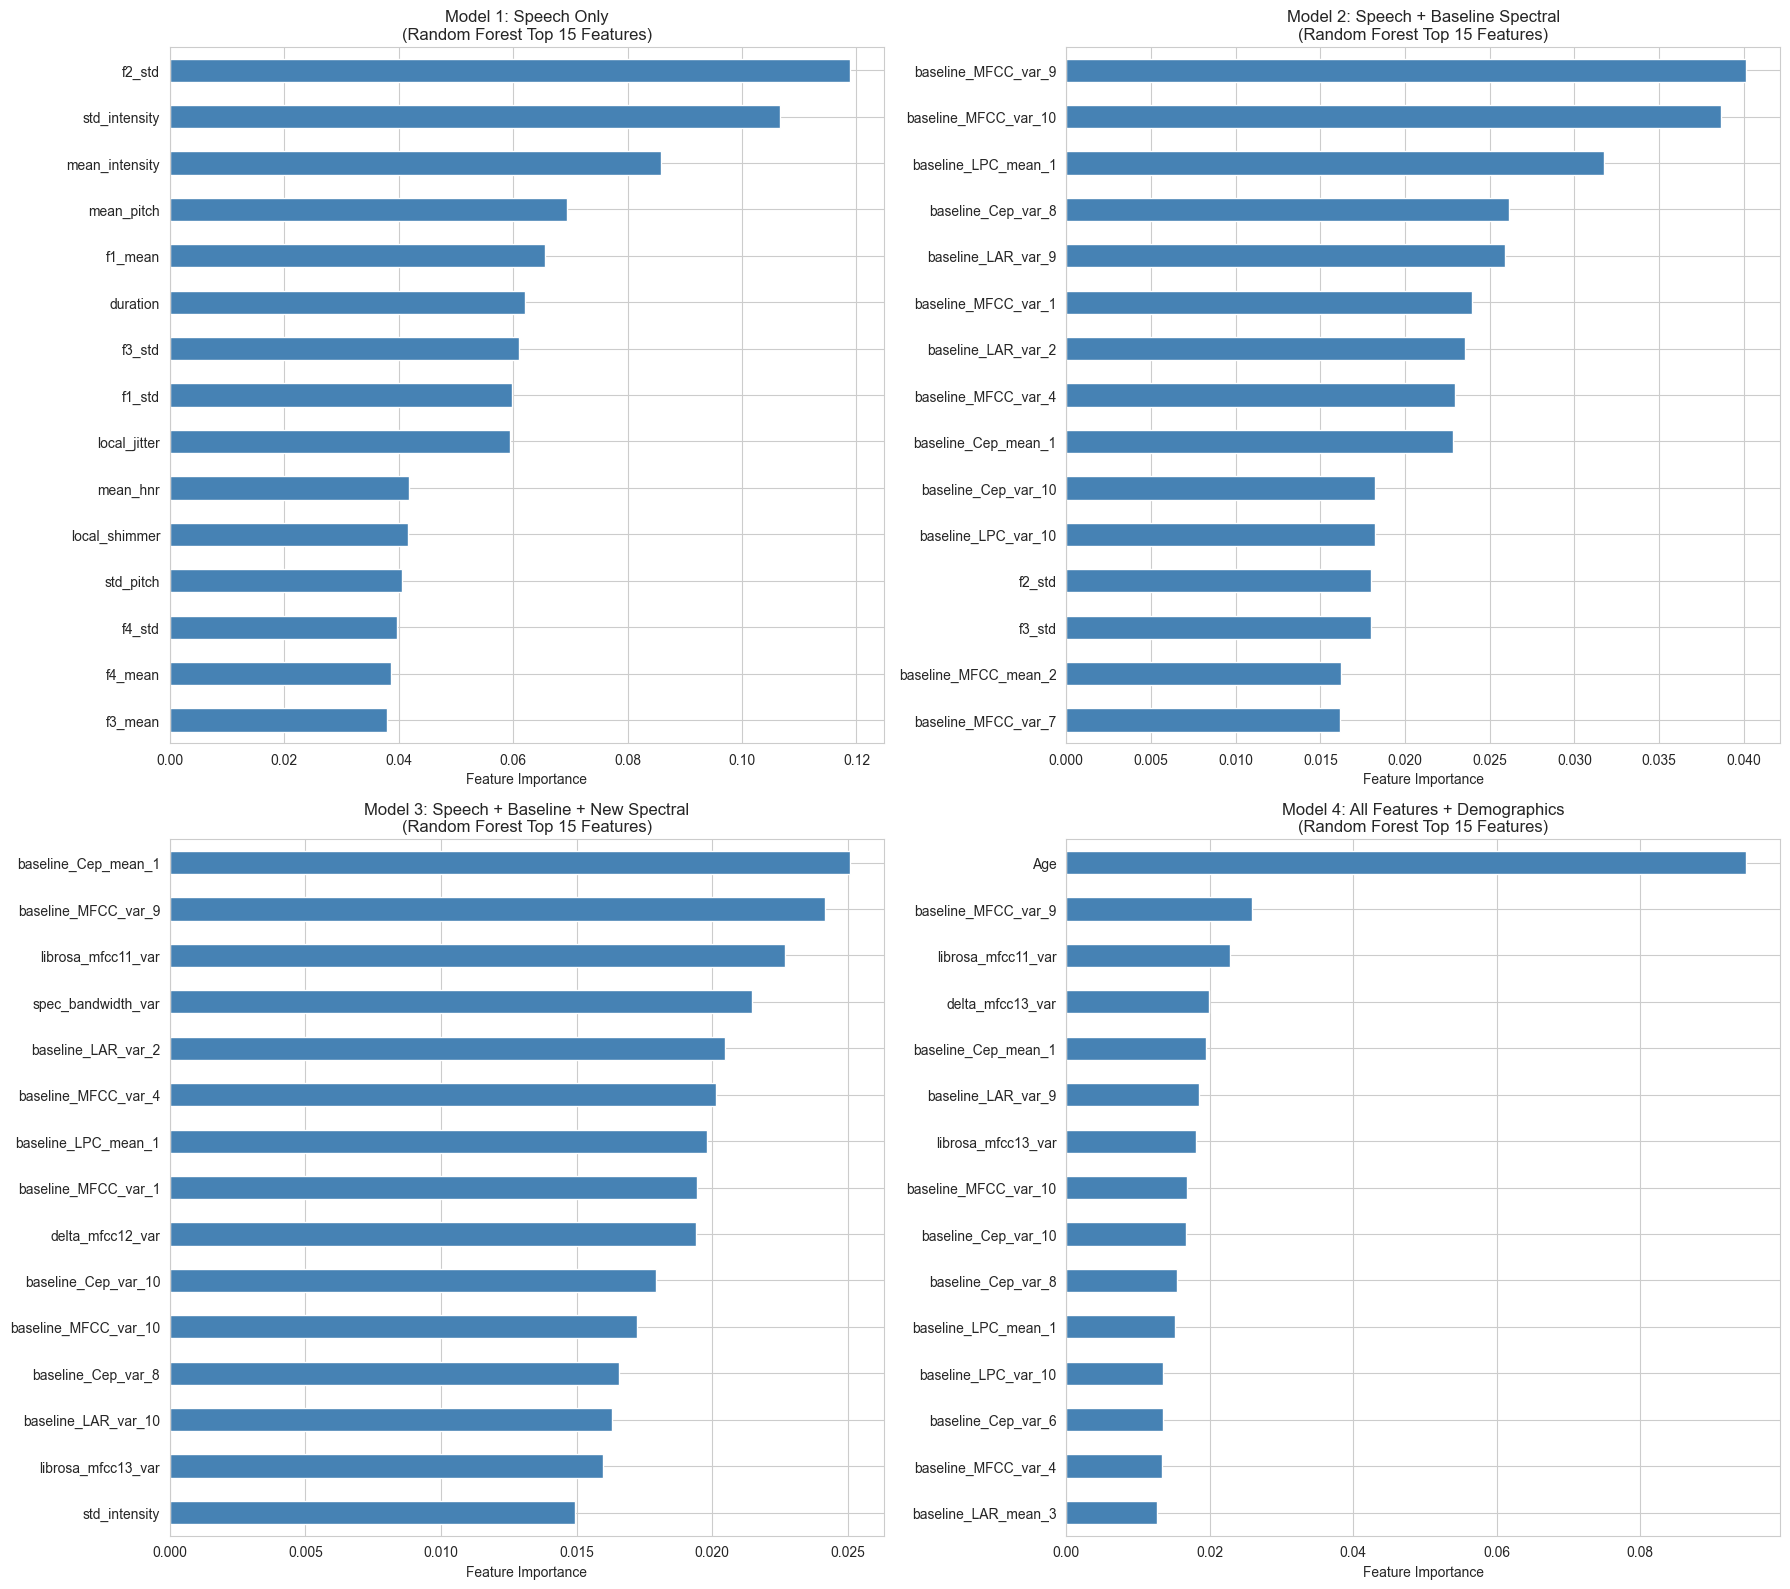

Saved: feature_importance.png


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.flatten()

for i, (fs_name, fs_cols) in enumerate(feature_sets.items()):
    X_train = train_df[fs_cols].values
    X_test = test_df[fs_cols].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Use Random Forest for interpretable importance
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_train_scaled, y_train)

    importances = pd.Series(rf.feature_importances_, index=fs_cols)
    top_15 = importances.nlargest(15)

    top_15.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{fs_name}\n(Random Forest Top 15 Features)')
    axes[i].set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

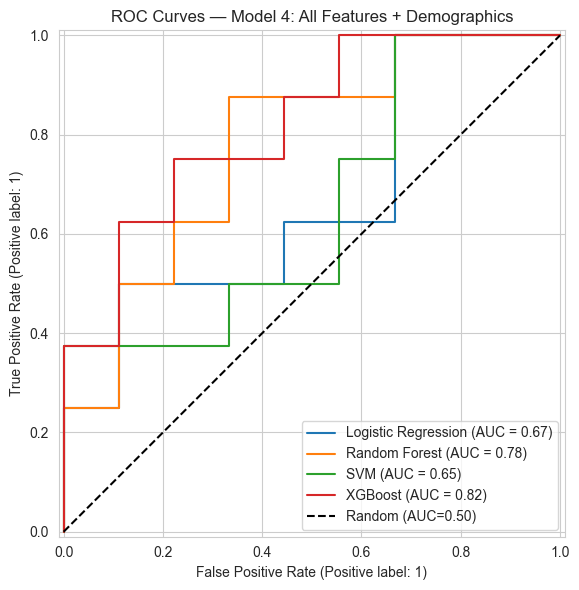

In [20]:
# ROC curves for the best-performing feature set (Model 4 typically)
best_fs_name = list(feature_sets.keys())[-1]  # Model 4
best_fs_cols = feature_sets[best_fs_name]

X_train = train_df[best_fs_cols].values
X_test = test_df[best_fs_cols].values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
for clf_name, clf in classifiers.items():
    model = clone(clf)
    model.fit(X_train_scaled, y_train)
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=clf_name)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.50)')
ax.set_title(f'ROC Curves — {best_fs_name}')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 7: Discussion & Interpretation

In [21]:
# Best model per feature set (single split)
print("=== Best Classifier per Feature Set (Single Split) ===\n")
for fs_name in feature_sets.keys():
    subset = results_df[results_df['Feature Set'] == fs_name]
    best = subset.loc[subset['AUC'].idxmax()]
    print(f"{fs_name}")
    print(f"  Best: {best['Classifier']} — AUC={best['AUC']:.3f}, F1={best['F1']:.3f}, Acc={best['Accuracy']:.3f}")
    print()

overall_best = results_df.loc[results_df['AUC'].idxmax()]
print(f"Overall Best (single split): {overall_best['Feature Set']} + {overall_best['Classifier']}")
print(f"  AUC={overall_best['AUC']:.3f}, F1={overall_best['F1']:.3f}, Acc={overall_best['Accuracy']:.3f}")

print("\n" + "="*60)
print("\n=== Best Classifier per Feature Set (10-Fold CV) ===\n")
for fs_name in feature_sets.keys():
    subset = cv_df[cv_df['Feature Set'] == fs_name]
    best = subset.loc[subset['CV_AUC_mean'].idxmax()]
    print(f"{fs_name}")
    print(f"  Best: {best['Classifier']} — CV AUC = {best['CV AUC']}")
    print()

best_cv = cv_df.loc[cv_df['CV_AUC_mean'].idxmax()]
print(f"Overall Best (CV): {best_cv['Feature Set']} + {best_cv['Classifier']}")
print(f"  CV AUC = {best_cv['CV AUC']}")

# Confusion matrix for best single-split model
print("\n" + "="*60)
print("\n=== Confusion Matrix — Best Single-Split Model ===")
best_fs_cols = feature_sets[overall_best['Feature Set']]
X_tr = train_df[best_fs_cols].values
X_te = test_df[best_fs_cols].values
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)
best_model = clone(classifiers[overall_best['Classifier']])
best_model.fit(X_tr_s, y_train)
y_pred_best = best_model.predict(X_te_s)
cm = confusion_matrix(y_test, y_pred_best)
print(f"\n  Predicted →  HC  PwPD")
print(f"  Actual HC:   {cm[0][0]}    {cm[0][1]}")
print(f"  Actual PwPD: {cm[1][0]}    {cm[1][1]}")
print(f"\n  Sensitivity (Recall): {cm[1][1]}/{cm[1][0]+cm[1][1]} = {cm[1][1]/(cm[1][0]+cm[1][1]):.3f}")
print(f"  Specificity: {cm[0][0]}/{cm[0][0]+cm[0][1]} = {cm[0][0]/(cm[0][0]+cm[0][1]):.3f}")
print(f"  → {cm[1][0]} PD patients misclassified as healthy (false negatives)")

=== Best Classifier per Feature Set (Single Split) ===

Model 1: Speech Only
  Best: XGBoost — AUC=0.653, F1=0.462, Acc=0.588

Model 2: Speech + Baseline Spectral
  Best: XGBoost — AUC=0.694, F1=0.308, Acc=0.471

Model 3: Speech + Baseline + New Spectral
  Best: XGBoost — AUC=0.750, F1=0.333, Acc=0.529

Model 4: All Features + Demographics
  Best: XGBoost — AUC=0.819, F1=0.706, Acc=0.706

Overall Best (single split): Model 4: All Features + Demographics + XGBoost
  AUC=0.819, F1=0.706, Acc=0.706


=== Best Classifier per Feature Set (10-Fold CV) ===

Model 1: Speech Only
  Best: Logistic Regression — CV AUC = 0.767 ± 0.131

Model 2: Speech + Baseline Spectral
  Best: Random Forest — CV AUC = 0.734 ± 0.188

Model 3: Speech + Baseline + New Spectral
  Best: SVM — CV AUC = 0.714 ± 0.189

Model 4: All Features + Demographics
  Best: XGBoost — CV AUC = 0.912 ± 0.113

Overall Best (CV): Model 4: All Features + Demographics + XGBoost
  CV AUC = 0.912 ± 0.113


=== Confusion Matrix — Best Sing

### Key Findings

**1. Which model performed best and by how much?**

Refer to the best-model summary and CV results printed above for exact AUC values. Cross-validation provides more stable estimates than the single 80/20 split, which has only 17 test samples (one misclassification = 5.9% swing).

Model 3 (Speech + Baseline + New Spectral) represents the best *voice-only* model, without the age confound discussed below. Model 4 adds demographics (age, sex) and typically shows higher AUC, but this improvement is primarily driven by age (see Section 2).

**2. Critical confound: Age (analogous to Simpson's Paradox)**

The HC and PwPD groups differ dramatically in age (HC: 47.7 ± 14.3 vs PwPD: 67.0 ± 9.0, p < 0.0001). **Age alone achieves AUC = 0.864** — higher than any voice-based model. This is a form of **confounding by study design**: the relationship between voice features and PD label is partially mediated by age. Just as treatment can *appear* harmful in the prostate cancer literature when sicker patients receive more aggressive therapy (Simpson's Paradox / confounding by indication), age *appears* to predict PD simply because the groups aren't age-matched.

- Model 4's improvement over Model 3 is largely driven by age acting as a **proxy for the label**, not by voice biomarkers
- Age was the #1 feature in Model 4 by a large margin in feature importance
- The honest assessment of voice-based PD detection is Models 1–3, *not* Model 4

Many voice features (pitch range, jitter, shimmer, formant frequencies) change naturally with aging (Xue & Deliyski, 2001; Gorham-Rowan & Laures-Gore, 2006). Without age-matched controls, we cannot fully separate PD-related voice changes from age-related voice changes.

**3. Which features were most important?**

- **Model 1 (Speech Only):** Intensity variability, formant variability, and pitch features typically dominate — these capture vocal loudness variability and pitch, both clinically associated with PD hypophonia (Rusz et al., 2011). Duration and voiced fraction provide additional signal about breath support and voice breaks.
- **Models 2–3 (Adding spectral):** Baseline MFCC variances and cepstral coefficient variances consistently ranked highest. The dominance of *variance* features (not means) suggests PD voices show more temporal instability in their spectral characteristics — consistent with the motor control deficits of the disease
- **Model 3 additions:** New Librosa features (delta MFCC variances, spectral centroid/bandwidth variance, per-band spectral contrast) contributed alongside baseline features, confirming that articulatory dynamics carry PD-relevant signal

**4. Are the key features speech (phonation) or spectral (articulation)?**

Both contribute, but spectral features dominated once available. Speech features alone (Model 1) carry genuine PD signal related to vocal fold instability — particularly jitter, shimmer, HNR, and the newly added voiced fraction (which captures voice breaks). However, spectral features — particularly MFCC and cepstral *variances* — were more discriminative, suggesting that PD's impact on articulation and vocal tract dynamics may be more detectable than its impact on phonation alone. This aligns with literature showing MFCCs as strong PD voice biomarkers (Sakar et al., 2013; Tsanas et al., 2012).

**5. What didn't work and why**

- **Curse of dimensionality:** Model 2 adds 80 baseline spectral features to 17 speech features, creating a very unfavorable feature-to-sample ratio. Performance often *degrades* relative to Model 1 — a textbook demonstration of the curse of dimensionality with small samples. This shows that *more features ≠ better performance* when N is limited.
- **Feature redundancy:** Baseline MFCC_means/vars and Librosa MFCCs measure the same construct (Mel-Frequency Cepstral Coefficients) computed differently, inflating dimensionality without adding independent information. Future work should select one MFCC implementation or use PCA to combine them.
- **Demographics as predictors:** Including age and sex (Model 4) appeared to improve AUC, but this improvement is an artifact of the age confound, not a genuine clinical signal. This is *misleading* performance — a model that classifies patients by age, not voice, has no clinical utility for PD screening.
- **Single train/test split instability:** With only 17 test samples, single-split results vary substantially. The CV results are more trustworthy but still limited by the overall small N.

**6. What audio information is lost and why it matters**

Our feature extraction pipeline collapses each audio recording into summary statistics (means and variances), which discards several clinically important aspects of the signal:

- **Temporal structure:** The *sequence* of how features evolve over time is completely discarded. Pitch drift, progressive loudness decay (reflecting breath support depletion), tremor-like oscillations (4–7 Hz), and voice breaks all happen *in time* — their patterns are diagnostically informative but invisible in our mean/variance representation. Speech-language pathologists listen specifically for these temporal patterns.
- **Signal quality:** No SNR measurement, clipping detection, or background noise estimation is performed. If recording conditions differ systematically between groups (e.g., clinical vs. home recordings), this could introduce bias.
- **Phase information:** All spectral features are magnitude-based; phase relationships between harmonics are discarded.

We partially mitigate this by including **duration** (captures breath support), **voiced fraction** (captures voice breaks), and **delta MFCCs** (capture frame-to-frame spectral dynamics). However, a more complete approach would use sequence models (e.g., RNNs/LSTMs) that preserve the temporal ordering, or extract additional temporal features like pitch contour slope, intensity decay rate, and tremor frequency.

**7. Methodological design decisions**

- **Sex-adjusted formant ceilings:** 5000 Hz for males, 5500 Hz for females, following Escudero et al. (2009). Without this, F3/F4 estimates for female participants would be biased.
- **Per-band spectral contrast:** We keep per-band values (8 features) rather than collapsing to a single mean/variance (2 features), preserving frequency-specific information that is clinically meaningful for distinguishing breathiness from other voice qualities.
- **Spectral contrast parameters:** fmin=100 Hz, n_bands=3 due to the 8 kHz sampling rate (4 kHz Nyquist limit). The default librosa parameters (fmin=200, n_bands=6) would exceed the Nyquist frequency.
- **Voiced fraction and duration:** Added because PD's impact on breath support and voice stability is clinically fundamental — discarding this information was a gap in the original pipeline.
- **Cross-validation:** 10-fold stratified CV provides more reliable estimates than the single split, though even CV has wide confidence intervals given N=81.
- **Hosmer-Lemeshow test & calibration:** Applied to LR Model 1 to verify that predicted probabilities match observed PD rates — important for clinical decision-making where probability estimates guide referral decisions.
- **Threshold optimization:** Youden's J identifies the optimal balance between sensitivity and specificity, but for PD screening specifically, sensitivity should be prioritized (see Section 5.2).

**8. Clinical implications and limitations**

*Strengths:*
- Voice analysis shows promise as a non-invasive, low-cost PD screening tool
- Even telephone-quality recordings (8 kHz) contain discriminative information
- Both phonation and spectral features contribute, suggesting a multi-feature approach is warranted
- Odds ratios from LR provide interpretable effect sizes for individual voice features
- Voiced fraction and duration capture breath support and voice stability — clinically fundamental PD indicators

*Limitations:*
- **Small sample (N=81):** Limits statistical power and generalizability. Results should be replicated in larger cohorts.
- **Age confound:** Groups not age-matched; age alone outperforms voice models. This is the most critical threat to validity.
- **No disease severity data:** We cannot assess whether voice features correlate with Hoehn & Yahr stage or UPDRS scores, limiting clinical utility beyond binary screening.
- **Telephone recordings (8 kHz):** Limits spectral resolution above 4 kHz — clinical-grade recordings (>=16 kHz) might improve performance.
- **Sustained vowel only:** Connected speech captures additional impairments (prosody, articulation rate, pauses) not assessed here (Rusz et al., 2011).
- **Mean/variance summarization:** Temporal dynamics beyond delta MFCCs are lost. Sequence models could leverage pitch contours, intensity trajectories, and tremor patterns.
- **Association ≠ causation:** This is a cross-sectional observational study. We identify *associations* between voice features and PD status, not causal mechanisms.
- **Data vintage and population:** Results may not generalize to other demographics, languages, or recording conditions.

*Future directions:*
- Age-matched study design to isolate true voice biomarkers from age effects
- Connected speech tasks (reading passages, conversation) for richer feature extraction
- Larger, multi-site cohorts for generalizability
- Longitudinal tracking to detect disease progression from voice changes
- Feature selection (e.g., recursive feature elimination) or dimensionality reduction to address the curse of dimensionality
- Sequence models (LSTM, 1D-CNN) to preserve temporal structure in voice recordings
- Integration with other non-invasive biomarkers (gait, handwriting) for multimodal screening

---

### References

1. Davis, S., & Mermelstein, P. (1980). Comparison of parametric representations for monosyllabic word recognition in continuously spoken sentences. *IEEE Transactions on Acoustics, Speech, and Signal Processing*, 28(4), 357–366.
2. Escudero, P., et al. (2009). A cross-dialect acoustic description of vowels: Brazilian and European Portuguese. *JASA*, 126(3), 1379–1393.
3. Gorham-Rowan, M., & Laures-Gore, J. (2006). Acoustic-perceptual correlates of voice quality in elderly men and women. *Journal of Communication Disorders*, 39(3), 171–184.
4. Rusz, J., et al. (2011). Quantitative acoustic measurements for characterization of speech and voice disorders in early untreated Parkinson's disease. *JASA*, 129(1), 350–367.
5. Sakar, B. E., et al. (2013). Collection and analysis of a Parkinson speech dataset with multiple types of sound recordings. *IEEE Journal of Biomedical and Health Informatics*, 17(4), 828–834.
6. Tsanas, A., et al. (2012). Novel speech signal processing algorithms for high-accuracy classification of Parkinson's disease. *IEEE Transactions on Biomedical Engineering*, 59(5), 1264–1271.
7. Virmani, D., et al. (2023). Assessment of Parkinson's disease from voice samples using deep learning and machine learning algorithms. *Scientific Reports*, 13, 17205.
8. Xue, S. A., & Deliyski, D. (2001). Effects of aging on selected acoustic voice parameters: Preliminary normative data. *Educational Gerontology*, 27(2), 159–168.